In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Проверка наличия CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 1. Загрузка данных
# 2. Предобработка данных (Измерения каждые 5 минут)
data_sim = pd.read_csv('adolescent#001.csv')
data_hov5 = pd.read_csv('hov_horizon5.csv')
data_hov10 = pd.read_csv('hov_horizon10.csv')
data_hov15 = pd.read_csv('hov_horizon15.csv')
data_hov30 = pd.read_csv('hov_horizon30.csv')
print(len(data_hov5), len(data_hov10), len(data_hov15), len(data_hov30))

data_sim = data_sim.head(len(data_hov5)//5)
data_sim = data_sim[['BG', 'CHO', 'insulin']]
print(len(data_sim))
#data_hov = pd.read_csv('datatest_hov.csv')
#data_hov = data_hov['BG']

data_sim.head()





Using device: cuda
10075 10075 10075 10075
2015


,BG,CHO,insulin
0,149.02,0.0,0.013933
1,149.02,0.0,0.013933
2,149.02,0.0,0.013933
3,149.02,0.0,0.013933
4,149.02,0.0,0.013933


In [10]:
#Группировка данных для обучения
def addHovorkaFeature(horizon, data_sim, data_hov):
  #horizon - шаг прогнозирования в минутах

  #Весь датасет с шагом в 5 минут   #Отрезаем последние данные, согласно horizon(Там nan)
  data_values_hov = data_hov.values[::5]
  print(data_values_hov)

  #Подсказки говорки на след итерацию
  #Сдвиг на horizon минут вверх (На X_0 элементе я хочу знать, что выдала говорка на y_0 элементе предикта)
  data_values_hov = np.roll(data_values_hov, -int(horizon/5), axis=0)
  data_values_hov = data_values_hov[:-int(horizon/5)]

  data_values_3 = data_sim.values[::5][:-int(horizon/5)] #Датасет 3 фичи

  data_values_4 = np.column_stack((data_values_3, data_values_hov)) #Датасет с фичей (Есть Nan вконце)
  #print(np.any(np.isnan(data_values_4)))

  print(data_values_4)
  return data_values_3, data_values_4

def addHovorkaFeatureUpdate(data_sim, data_hov):
  data_hov = data_hov.values[: :5]
  data_values = data_sim.values
  print("LEN DATA ",len(data_hov), len( data_values))
  data_valuesHov = np.column_stack((data_values, data_hov))
  print("DATA_VAL " ,data_values[:10])
  print("DATAHOV VAL," ,data_valuesHov[:10])
  print("END HOV")

  return data_values, data_valuesHov



def addOtherFeatures(data_value):
    # Сдвиг на 1 и 2, заполняем пропуски первым элементом
    lag_1 = np.roll(data_value[:, 0], 1)
    lag_2 = np.roll(data_value[:, 0], 2)
    lag_1[0] = data_value[0, 0]  # Заполняем первый элемент, так как он был сдвинут
    lag_2[:2] = data_value[0, 0]  # Заполняем первые два элемента

    # Добавляем новые признаки как новые столбцы к numpy массиву
    data_value = np.column_stack((data_value, lag_1, lag_2))

    # Рассчитываем среднее значение по лагам (последние 2 столбца dv)
    mean_lag = np.mean(data_value[:, -2:], axis=1)

    # Добавляем среднее значение как новый столбец
    data_value = np.column_stack((data_value, mean_lag))

    return data_value




In [11]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_window, output_window, horizon):
        self.data = data
        self.input_window = input_window
        self.output_window = output_window

        if(len(data) - input_window - horizon >=0):
          self.length = len(data) - input_window - horizon
        else:
          self.length=0

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        # Входная последовательность X: данные от index до index + input_window
        x = self.data[index : index + self.input_window, : -1] #Перые 7 столбцов
        # Целевая последовательность Y: смещённая на horizon  шаг вперёд последовательность BG
        y = self.data[index + horizon : index + horizon + self.input_window, -1]  # BG (последний столбец)
        return x, y


# 5. Определение модели LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_window=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_window)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))

        out = self.fc(out)
        return out

In [12]:
import numpy as np
import matplotlib.pyplot as plt
'''
def plot_results_compare(outputs_list, y_test, scaler, losses, feature_indices):
    """
    Функция для визуализации результатов предсказания нескольких моделей с разными наборами признаков.

    Параметры:
    - outputs_list: список тензоров предсказаний для каждой модели.
    - y_test: реальные значения (тензор).
    - scaler: один MinMaxScaler, обученный на полном наборе признаков.
    - losses: список значений потерь для каждой модели.
    - feature_indices: список списков с индексами признаков для каждой модели.
    """

    # Преобразование y_test для визуализации (предполагается, что используем полный набор признаков)
    y_test_np = y_test.cpu().numpy().reshape(-1, 1)
    y_test_full = np.zeros((y_test_np.shape[0], scaler.n_features_in_))  # Создаем массив с 7 признаками
    y_test_full[:, 0] = y_test_np[:, 0]
    y_test_inv = scaler.inverse_transform(y_test_full)[:, 0]

    plt.figure(figsize=(14, 7))
    output_time = np.arange(0, y_test_inv.shape[0])
    plt.plot(output_time, y_test_inv, label='Реальные данные (BG)', color='black', marker='o')

    # Проход по каждому набору предсказаний и построение графиков
    for i, outputs in enumerate(outputs_list):
        # Обратное преобразование предсказаний для текущей модели
        outputs_np = outputs.cpu().numpy().reshape(-1, 1)
        outputs_full = np.zeros((outputs_np.shape[0], scaler.n_features_in_))  # Создаем массив с 7 признаками
        outputs_full[:, feature_indices[i][0]] = outputs_np[:, 0]  # Заполняем только нужные признаки

        # Выполняем обратное преобразование и извлекаем нужный признак
        outputs_inv = scaler.inverse_transform(outputs_full)[:, feature_indices[i][0]]

        # Название модели на основе количества признаков
        label = f'Модель с {len(feature_indices[i])} признаками - Loss: {losses[i]:.4e}'

        # Построение графика для текущей модели
        plt.plot(output_time, outputs_inv, label=label, marker='o')

    plt.legend()
    plt.xlabel('Время (минуты*5)')
    plt.ylabel('Уровень глюкозы в крови')
    plt.title('Прогнозирование уровня глюкозы в крови для нескольких моделей')
    plt.show()
'''

'\ndef plot_results_compare(outputs_list, y_test, scaler, losses, feature_indices):\n    """\n    Функция для визуализации результатов предсказания нескольких моделей с разными наборами признаков.\n\n    Параметры:\n    - outputs_list: список тензоров предсказаний для каждой модели.\n    - y_test: реальные значения (тензор).\n    - scaler: один MinMaxScaler, обученный на полном наборе признаков.\n    - losses: список значений потерь для каждой модели.\n    - feature_indices: список списков с индексами признаков для каждой модели.\n    """\n\n    # Преобразование y_test для визуализации (предполагается, что используем полный набор признаков)\n    y_test_np = y_test.cpu().numpy().reshape(-1, 1)\n    y_test_full = np.zeros((y_test_np.shape[0], scaler.n_features_in_))  # Создаем массив с 7 признаками\n    y_test_full[:, 0] = y_test_np[:, 0]\n    y_test_inv = scaler.inverse_transform(y_test_full)[:, 0]\n\n    plt.figure(figsize=(14, 7))\n    output_time = np.arange(0, y_test_inv.shape[0])\n

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error


def plot_results_compare(outputs_list, y_test, losses, feature_indices, index):
    """
    Функция для визуализации результатов предсказания нескольких моделей с разными наборами признаков.

    Параметры:
    - outputs_list: список тензоров предсказаний для каждой модели.
    - y_test: реальные значения (тензор).
    - losses: список значений потерь для каждой модели.
    - feature_indices: список списков с индексами признаков для каждой модели.
    """

    # Преобразуем y_test в numpy и убираем обратное преобразование
    y_test_np = y_test.cpu().numpy().reshape(-1, 1)

    plt.figure(figsize=(14, 7))
    output_time = np.arange(0, y_test_np.shape[0])
    plt.plot(output_time, y_test_np, label='Реальные данные (BG)', color='black', marker='o')

    # Проход по каждому набору предсказаний и построение графиков
    for i, outputs in enumerate(outputs_list):
        # Получаем предсказания текущей модели
        outputs_np = outputs.cpu().numpy().reshape(-1, 1)

        R2loss = r2_score(y_test_np, outputs_np)
        rmse = root_mean_squared_error(y_test_np, outputs_np)
        mape = np.mean(np.abs((y_test_np - outputs_np) / y_test_np)) * 100


        # Название модели на основе количества признаков
        #label = f'Модель с {len(feature_indices[i])} признаками - Loss: {losses[i]:.4e}'
        label = f'Модель с {len(feature_indices[i])}f.  - RMSE: {rmse:.4e}, R2: {R2loss:0.4e},  MAPE: {mape:0.4e}'

        # Построение графика для текущей модели
        plt.plot(output_time, outputs_np, label=label, marker='o')

    plt.legend()
    plt.xlabel('Время (минуты * 5)')
    plt.ylabel('Уровень глюкозы в крови')
    plt.title(f'Прогнозирование уровня глюкозы в крови для нескольких моделей, index={index}')
    #plt.savefig(f'evaluate{index}.png', format='png')
    #files.download(f'evaluate{index}.png')
    plt.show()


In [60]:
import torch
from google.colab import files

def save_to_csv(outputs_list, y_test_last, index):
    """
    Сохраняет предсказания моделей и правильные значения в CSV файл.

    Параметры:
    - outputs_list: Список тензоров с выходами моделей.
    - y_test_last: Тензор с правильными значениями для теста.
    - filename: Имя файла для сохранения (по умолчанию "results.csv").
    """
    # Преобразуем y_test_last и элементы из outputs_list в numpy массивы
    y_test_last_np = y_test_last.cpu().numpy().flatten()  # преобразуем в одномерный массив
    outputs_list_np = [output.cpu().numpy().flatten() for output in outputs_list]  # преобразуем все выходы моделей

    # Соединяем все данные в один список
    data = {'y_test_last': y_test_last_np}

    # Добавляем выходы моделей в data
    for idx, output in enumerate(outputs_list_np):
        data[f'output_model_{idx+1}'] = output

    # Создаем DataFrame
    df = pd.DataFrame(data)

    # Сохраняем DataFrame в CSV файл
    df.to_csv(f'evaluate{index}.csv', index=False)
    print(f"Results saved to", f'evaluate{index}.csv')
    files.download(f'evaluate{index}.csv')

def evaluate_multiple_models(models, test_loader, scaler, device, criterion, index, feature_indices):
    """
    Функция для оценки нескольких моделей на одном тестовом примере и визуализации результатов.

    Параметры:
    - models: список обученных моделей.
    - test_loader: DataLoader с тестовыми данными.
    - scalers: список объектов MinMaxScaler для обратного преобразования для каждой модели.
    - device: устройство для вычислений (cuda или cpu).
    - criterion: функция потерь.
    - index: индекс тестового примера для оценки.
    - feature_indices: список списков с индексами признаков для каждой модели.
    """

    # Переводим модели в режим оценки
    for model in models:
        model.eval()

    counter = 0
    outputs_list = []


    with torch.no_grad():
        for x_test, y_test in test_loader:
            if counter == index:

                # Перемещаем данные на устройство
                x_test = x_test.float().to(device)
                y_test = y_test.float().to(device)
                losses = []
                for i, model in enumerate(models):
                    # Выбираем признаки для текущей модели
                    x_test_model = x_test[:, :, feature_indices[i]]

                    # Получаем предсказания для текущей модели
                    outputs = model(x_test_model)
                    outputs_last = outputs[:, 10:59]  # Подвыборка выходных данных
                    outputs_list.append(outputs_last)

                    # Подготавливаем y_test для расчета потерь и визуализации
                    y_test_last = y_test[:, 10:59].unsqueeze(-1)

                    # Рассчитываем потерю для текущей модели
                    loss = criterion(outputs_last, y_test_last).item()
                    losses.append(loss)

                break
            counter += 1




    # Вызываем функцию визуализации
    plot_results_compare(outputs_list, y_test_last, losses, feature_indices, index)
    #save_to_csv(outputs_list, y_test_last, index)




In [17]:
def train_multiple_models(models, optimizers, criterion, train_loader, validation_loader, num_epochs, scaler, device, feature_indices):
    """
    Функция для одновременной тренировки и валидации нескольких моделей с разными наборами признаков.

    Параметры:
    - models: список моделей.
    - optimizers: список оптимизаторов для каждой модели.
    - criterion: функция потерь.
    - train_loader: DataLoader с полным набором признаков.
    - validation_loader: DataLoader с данными для валидации, с полным набором признаков.
    - num_epochs: количество эпох.
    - scaler: MinMaxScaler, обученный на полном наборе признаков.
    - device: устройство (cpu или cuda).
    - feature_indices: список списков с индексами признаков для каждой модели.
    """

    for epoch in range(num_epochs):
        for model in models:
            model.train()

        epoch_losses = [0] * len(models)

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.float().to(device)
            y_batch = y_batch.float().to(device)

            # Обучение каждой модели
            for i, model in enumerate(models):
                optimizer = optimizers[i]
                optimizer.zero_grad()

                # Извлекаем нужные признаки для текущей модели
                x_batch_model = x_batch[:, :, feature_indices[i]]

                # Прогноз и вычисление потерь
                outputs = model(x_batch_model)
                loss = criterion(outputs, y_batch.unsqueeze(-1))

                # Обратное распространение ошибки и шаг оптимизации
                loss.backward()
                optimizer.step()

                epoch_losses[i] += loss.item()

        avg_losses = [epoch_loss / len(train_loader) for epoch_loss in epoch_losses]

        if (epoch+1) % 50 == 0:
            for i, avg_loss in enumerate(avg_losses):
                print(f'Epoch [{epoch+1}/{num_epochs}], AVG Loss for model {i+1}: {avg_loss:.6f}')

        # Валидация на каждые 50 эпох
        if (epoch + 1) % 50 == 0:
            validation_losses = [0] * len(models)

            with torch.no_grad():
                for counter, (x_val, y_val) in enumerate(validation_loader):
                    x_val = x_val.float().to(device)
                    y_val = y_val.float().to(device)

                    if counter == 0:
                        # Индексы последовательностей для визуализации
                        target_indices = [0, 63]

                        # Проход по каждой целевой последовательности
                        for target_index in target_indices:
                            if x_val.size(0) > target_index:
                                outputs_list = []  # Список для предсказаний всех моделей для одной последовательности
                                losses = []  # Список потерь для каждой модели
                                single_y_val = y_val[target_index:target_index + 1]
                                last_y_val = single_y_val[:, 10:59]

                                # Валидация каждой модели на целевой последовательности
                                for i, model in enumerate(models):
                                    x_val_model = x_val[:, :, feature_indices[i]]
                                    single_val_output = model(x_val_model)[target_index:target_index + 1]
                                    last_val_output = single_val_output[:, 10:59]

                                    # Вычисляем потери для этой последовательности
                                    single_loss = criterion(last_val_output, last_y_val.unsqueeze(-1)).item()
                                    losses.append(single_loss)

                                    # Добавляем предсказания модели для визуализации
                                    outputs_list.append(last_val_output)

                                # Визуализируем все модели на одном графике для текущей последовательности
                                plot_results_compare(outputs_list, last_y_val, losses, feature_indices)

                    # Сбор потерь для всех моделей на валидации
                    for i, model in enumerate(models):
                        model.eval()
                        x_val_model = x_val[:, :, feature_indices[i]]
                        val_outputs = model(x_val_model)
                        val_loss = criterion(val_outputs, y_val.unsqueeze(-1))
                        validation_losses[i] += val_loss.item()

                avg_val_losses = [val_loss / len(validation_loader) for val_loss in validation_losses]

                for i, avg_val_loss in enumerate(avg_val_losses):
                    print(f'AVG Val loss [{epoch+1}/{num_epochs}] for model {i+1}: {avg_val_loss:.6f}')


In [ ]:
'''
from sklearn.preprocessing import MinMaxScaler
def create_dataloader(horizon, data_sim, data_hov5, data_hov10, data_hov15, data_hov30):
  #data_values_default, data_values_hovFeature = addHovorkaFeature(horizon, data_sim, data_hov) #Датасет 3 фичи, датасет 3 фичи+говорка
  if horizon==5:
    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov5)
  elif horizon==10:
    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov10)
  elif horizon==15:
    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov15)
  elif horizon==30:
    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov30)

  #data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov30)
  data_values_otherFeatures = addOtherFeatures(data_values_default)#Датасет 3 фичи + авторегрессионные
  data_values_allFeatures = addOtherFeatures(data_values_hovFeature) #Датасет 3 фичи + Hovorka + авторегр


  # Нормализация данных
  scaler = MinMaxScaler()
  scaler.fit(data_values_allFeatures)  # 7 признаков (3 признака + Hovorka + авторегрессионные)
  data_values_scaled = scaler.transform(data_values_allFeatures)

  BG_original = data_values_default[:, 0]  # Исходный BG (первый столбец)
  data_values_with_BG = np.column_stack((data_values_scaled, BG_original))


  # 3. Разделение данных
  total_minutes = data_values_with_BG.shape[0]
  train_minutes = int(5 * 24 * 60 / 5) # Первые 5 дней
  validation_minutes = int(1 * 24 * 60 / 5) # Следующий 1 день
  test_minutes = total_minutes - train_minutes - validation_minutes # Последний день
  print(train_minutes, validation_minutes, test_minutes)
  train_data = data_values_with_BG[:train_minutes]
  validation_data = data_values_with_BG[train_minutes:train_minutes + validation_minutes]
  test_data = data_values_with_BG[train_minutes + validation_minutes:]




  # 4. Создание Dataset и DataLoader
  input_window = int((180 + 60) / 5)    # 180 минут минут + разгон 60 минут
  output_window = input_window

  # Создаем Dataset
  horizon = int(horizon/5) #Переводим в 5 минут/фрейм
  #print(len(test_data))
  train_dataset = TimeSeriesDataset(train_data, input_window, output_window, horizon)
  validation_dataset = TimeSeriesDataset(validation_data, input_window, output_window, horizon)
  test_dataset = TimeSeriesDataset(test_data, input_window, output_window, horizon)
    #print(test_dataset)

  print(train_dataset[0][0])
  print(train_dataset[0][1])
  print(len(train_dataset[0][0]))

  # Создаем DataLoader
  batch_size = 64
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
  test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


  print(len(train_dataset[0][-1]))
  return train_loader, validation_loader, test_loader, scaler
'''


'\nfrom sklearn.preprocessing import MinMaxScaler\ndef create_dataloader(horizon, data_sim, data_hov5, data_hov10, data_hov15, data_hov30): \n  #data_values_default, data_values_hovFeature = addHovorkaFeature(horizon, data_sim, data_hov) #Датасет 3 фичи, датасет 3 фичи+говорка\n  if horizon==5:\n    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov5)\n  elif horizon==10:\n    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov10)\n  elif horizon==15:\n    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov15)\n  elif horizon==30:\n    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov30)\n\n  #data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov30)\n  data_values_otherFeatures = addOtherFeatures(data_values_default)#Датасет 3 фичи + авторегрессионные\n  data_values_allFeatures = addOtherFeatures(data_v

In [18]:
from sklearn.preprocessing import MinMaxScaler

#прогноз на час вперед
#data_values_default, data_values_hovFeature = addHovorkaFeature(horizon, data_sim, data_hov) #Датасет 3 фичи, датасет 3 фичи+говорка
data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hov30)
data_values_otherFeatures = addOtherFeatures(data_values_default)#Датасет 3 фичи + авторегрессионные
data_values_allFeatures = addOtherFeatures(data_values_hovFeature) #Датасет 3 фичи + Hovorka + авторегр


# Нормализация данных
scaler = MinMaxScaler()
scaler.fit(data_values_allFeatures)  # 7 признаков (3 признака + Hovorka + авторегрессионные)
data_values_scaled = scaler.transform(data_values_allFeatures)

BG_original = data_values_default[:, 0]  # Исходный BG (первый столбец)
data_values_with_BG = np.column_stack((data_values_scaled, BG_original))


# 3. Разделение данных
total_minutes = data_values_with_BG.shape[0]
train_minutes = int(5 * 24 * 60 / 5) # Первые 5 дней
validation_minutes = int(1 * 24 * 60 / 5) # Следующий 1 день
test_minutes = total_minutes - train_minutes - validation_minutes # Последний день

train_data = data_values_with_BG[:train_minutes]
validation_data = data_values_with_BG[train_minutes:train_minutes + validation_minutes]
test_data = data_values_with_BG[train_minutes + validation_minutes:]






# 4. Создание Dataset и DataLoader
input_window = int((180 + 60) / 5)    # 180 минут минут + разгон 60 минут
output_window = input_window

# Создаем Dataset
horizon=30
horizon = int(horizon/5) #Переводим в 5 минут/фрейм
#print(len(test_data))
train_dataset = TimeSeriesDataset(train_data, input_window, output_window, horizon)
validation_dataset = TimeSeriesDataset(validation_data, input_window, output_window, horizon)
test_dataset = TimeSeriesDataset(test_data, input_window, output_window, horizon)
#print(test_dataset)

print(train_dataset[0][0])
print(train_dataset[0][1])
print(len(train_dataset[0][0]))

# Создаем DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


print(len(train_dataset[0][-1]))


LEN DATA  2015 2015
DATA_VAL  [[1.49020000e+02 0.00000000e+00 1.39333333e-02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02]
 [1.49020001e+02 0.00000000e+00 1.39333333e-02]
 [1.49020002e+02 0.00000000e+00 1.39333333e-02]
 [1.49020005e+02 0.00000000e+00 1.39333333e-02]
 [1.49020010e+02 0.00000000e+00 1.39333333e-02]
 [1.49020018e+02 0.00000000e+00 1.39333333e-02]]
DATAHOV VAL, [[1.49020000e+02 0.00000000e+00 1.39333333e-02 1.50185797e+02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02 1.50211776e+02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02 1.50249805e+02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02 1.50302142e+02]
 [1.49020000e+02 0.00000000e+00 1.39333333e-02 1.50370828e+02]
 [1.49020001e+02 0.00000000e+00 1.39333333e-02 1.50457648e+02]
 [1.49020002e+02 0.00000000e+00 1.39333333e-02 1.50564111e+02]
 [1.49020005e+02 0.00000000e+00 1.3

Epoch [50/700], AVG Loss for model 1: 338.099812
Epoch [50/700], AVG Loss for model 2: 339.964294
Epoch [50/700], AVG Loss for model 3: 332.344577
Epoch [50/700], AVG Loss for model 4: 337.673787


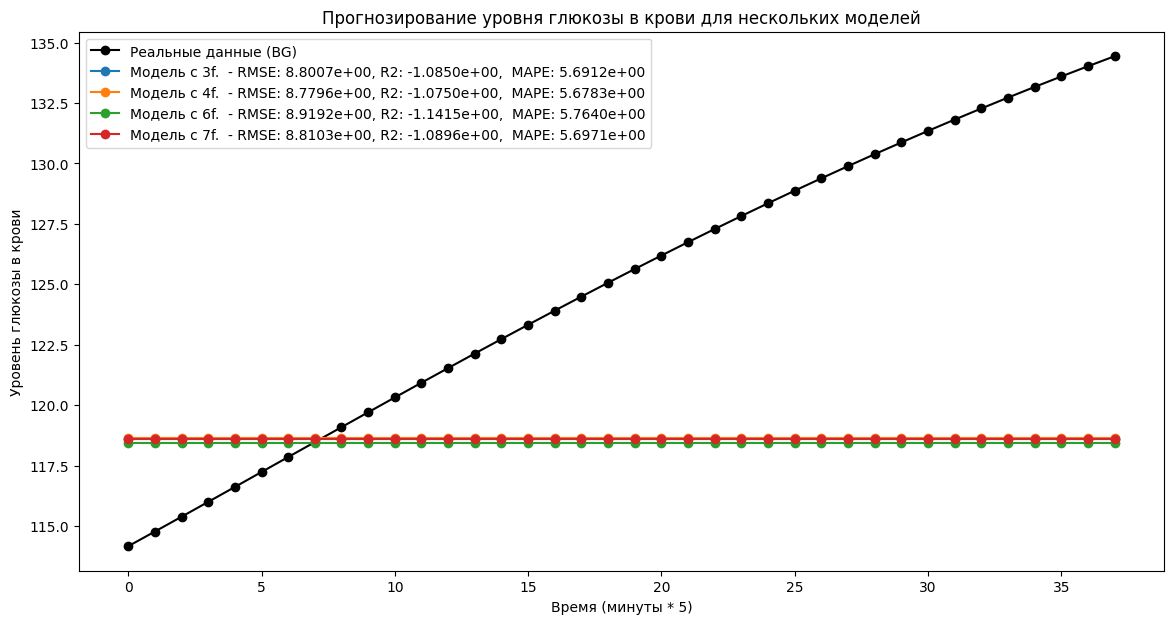

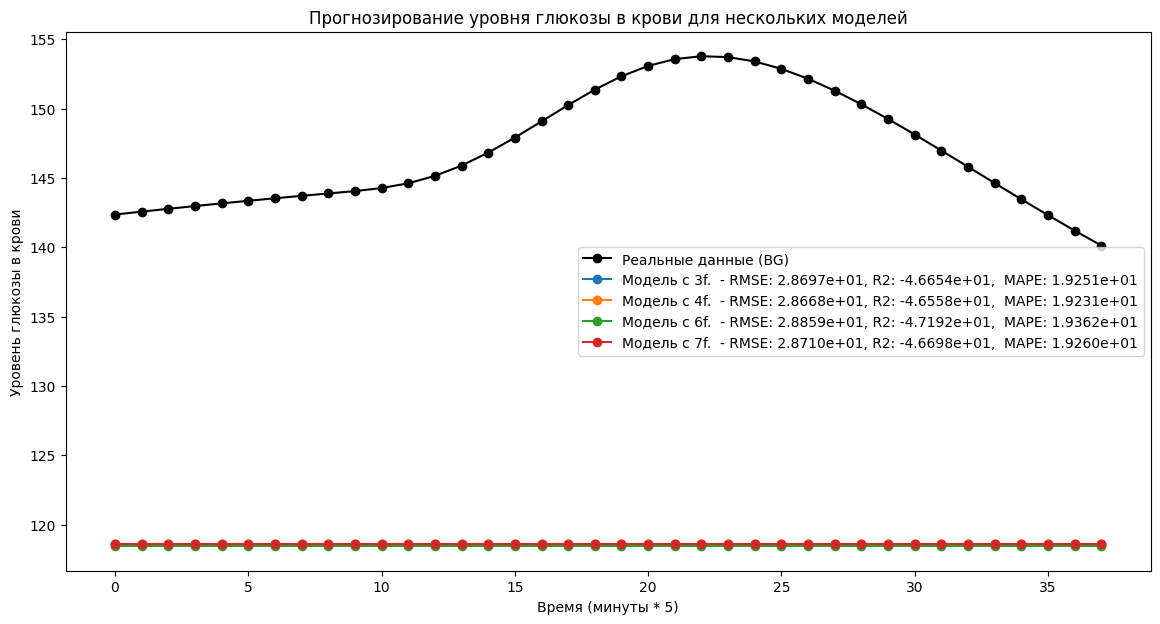

AVG Val loss [50/700] for model 1: 305.302807
AVG Val loss [50/700] for model 2: 307.322300
AVG Val loss [50/700] for model 3: 299.946098
AVG Val loss [50/700] for model 4: 305.009068
Epoch [100/700], AVG Loss for model 1: 330.432929
Epoch [100/700], AVG Loss for model 2: 334.470591
Epoch [100/700], AVG Loss for model 3: 7.292241
Epoch [100/700], AVG Loss for model 4: 341.490934


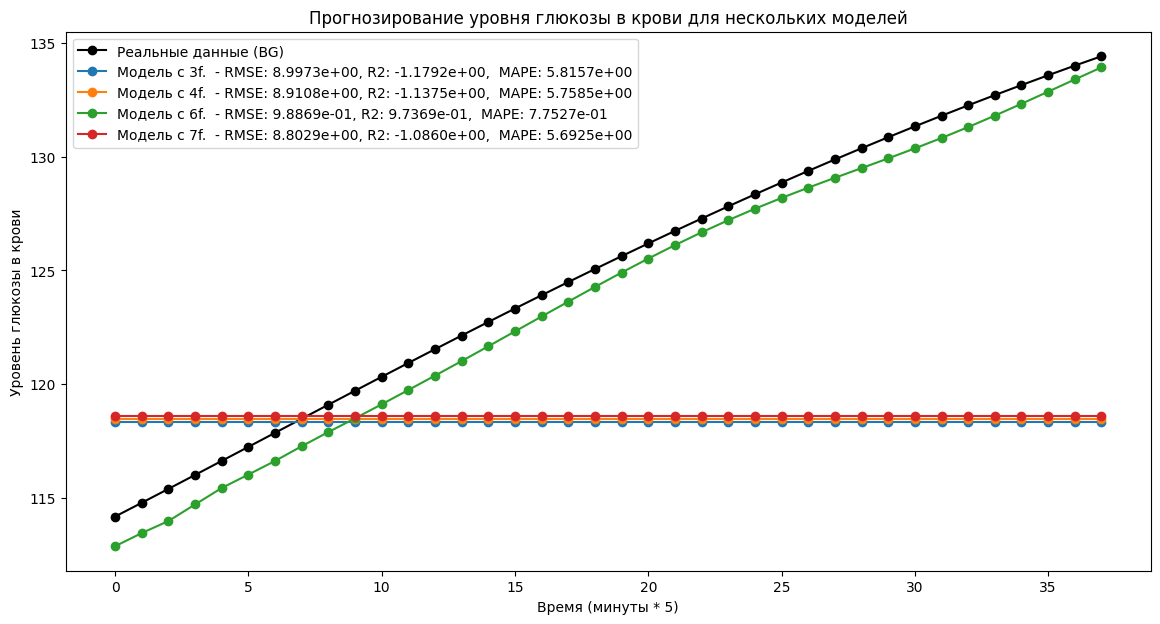

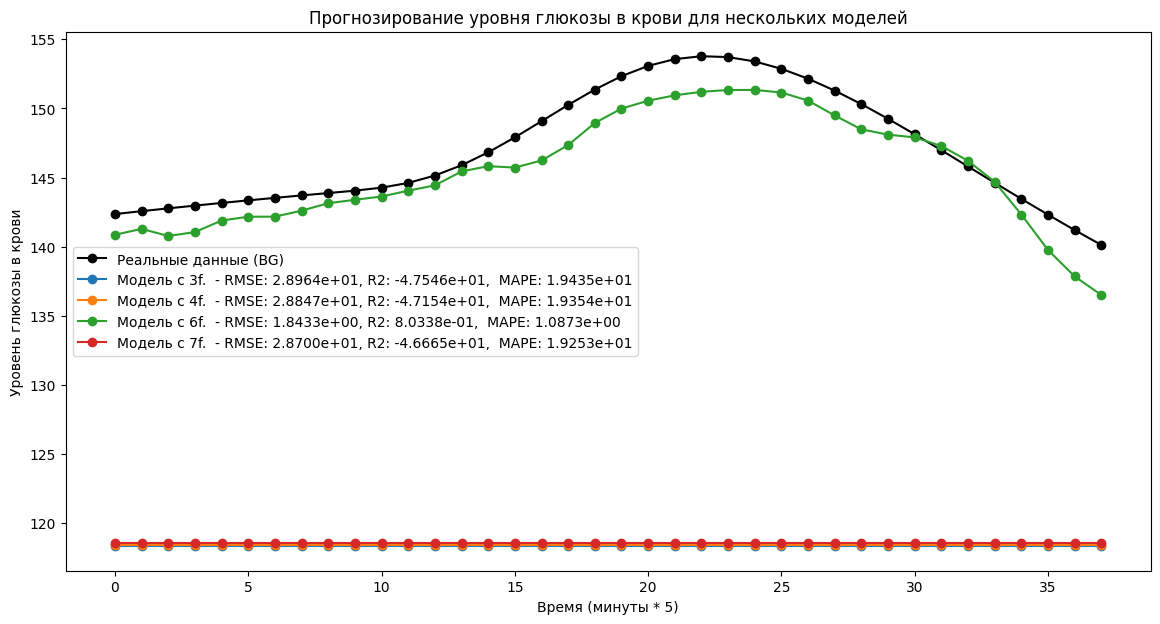

AVG Val loss [100/700] for model 1: 298.169889
AVG Val loss [100/700] for model 2: 302.391485
AVG Val loss [100/700] for model 3: 7.440406
AVG Val loss [100/700] for model 4: 309.627766
Epoch [150/700], AVG Loss for model 1: 246.120855
Epoch [150/700], AVG Loss for model 2: 331.078545
Epoch [150/700], AVG Loss for model 3: 1.921459
Epoch [150/700], AVG Loss for model 4: 297.675167


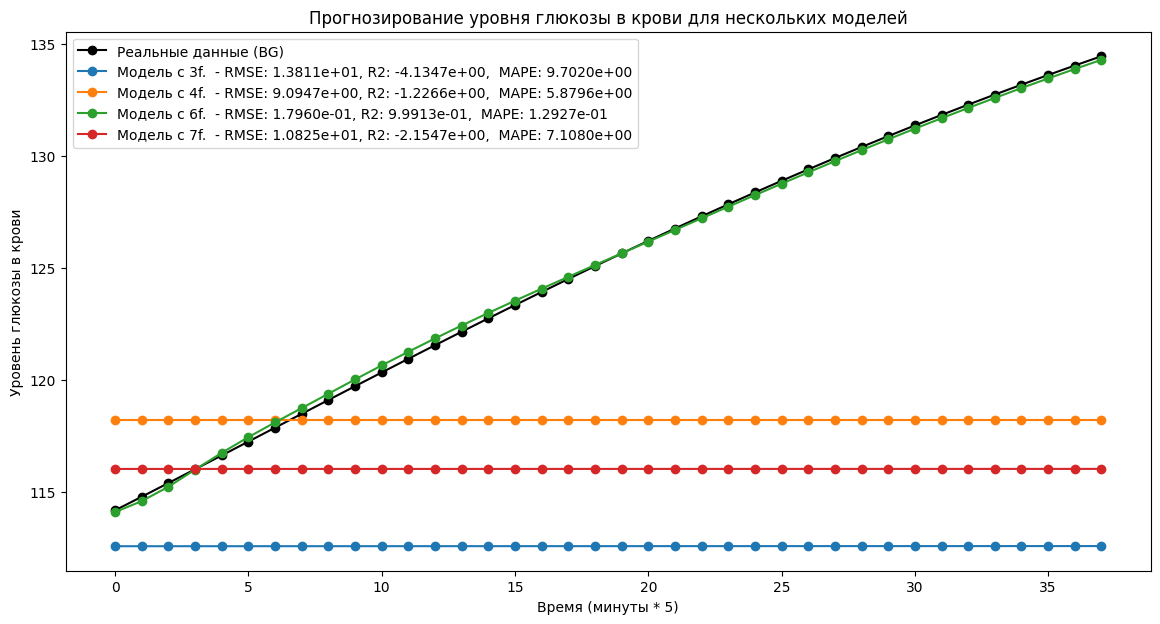

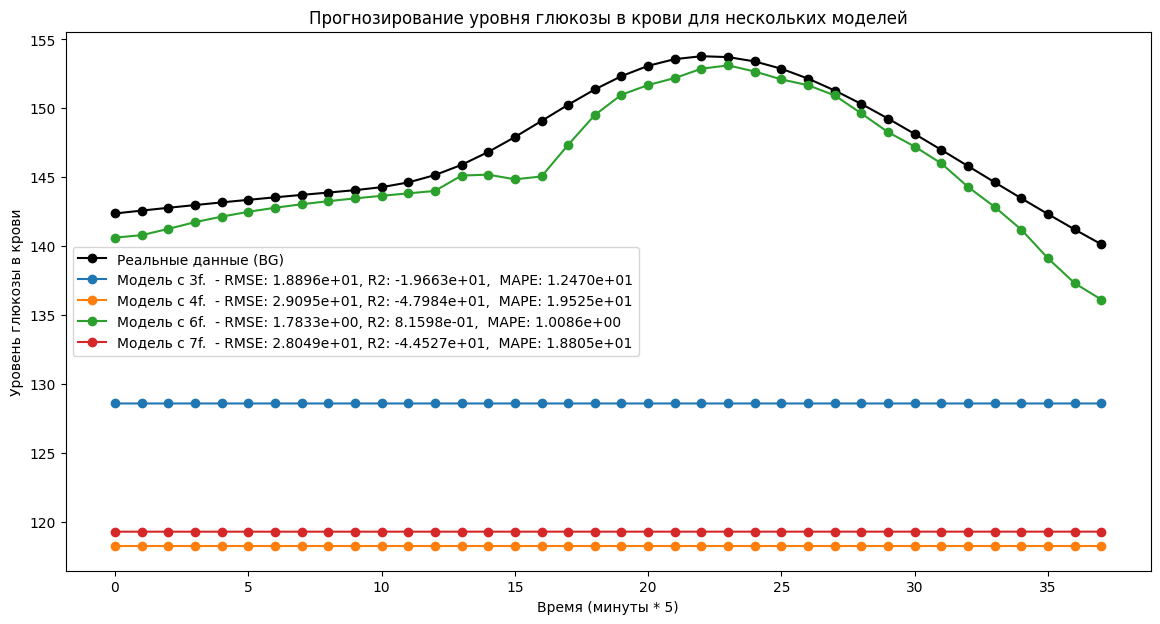

AVG Val loss [150/700] for model 1: 208.913460
AVG Val loss [150/700] for model 2: 301.124218
AVG Val loss [150/700] for model 3: 2.229494
AVG Val loss [150/700] for model 4: 278.026226
Epoch [200/700], AVG Loss for model 1: 7.071815
Epoch [200/700], AVG Loss for model 2: 129.088087
Epoch [200/700], AVG Loss for model 3: 1.452641
Epoch [200/700], AVG Loss for model 4: 1.870551


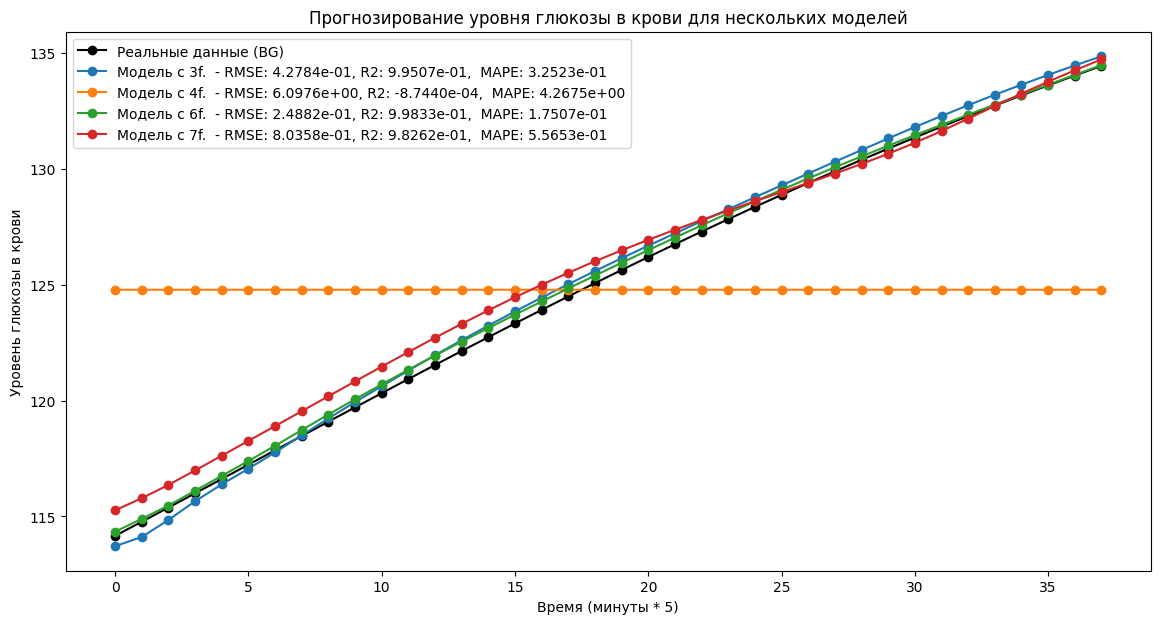

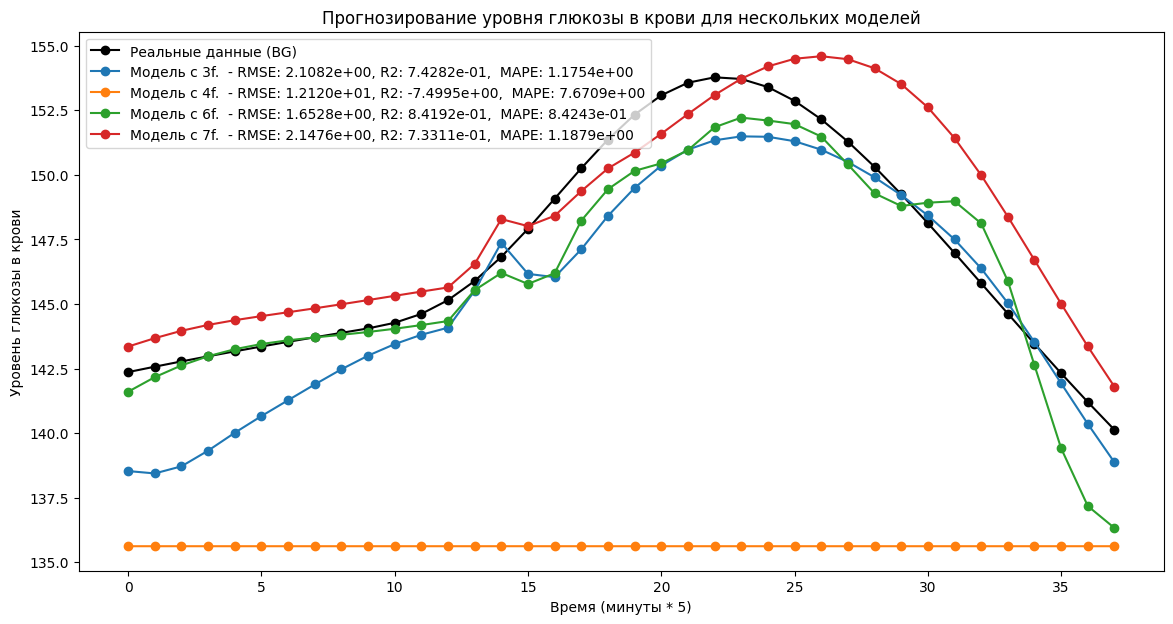

AVG Val loss [200/700] for model 1: 6.675970
AVG Val loss [200/700] for model 2: 116.104488
AVG Val loss [200/700] for model 3: 2.267493
AVG Val loss [200/700] for model 4: 2.822577
Epoch [250/700], AVG Loss for model 1: 4.355336
Epoch [250/700], AVG Loss for model 2: 14.243382
Epoch [250/700], AVG Loss for model 3: 1.070462
Epoch [250/700], AVG Loss for model 4: 1.014525


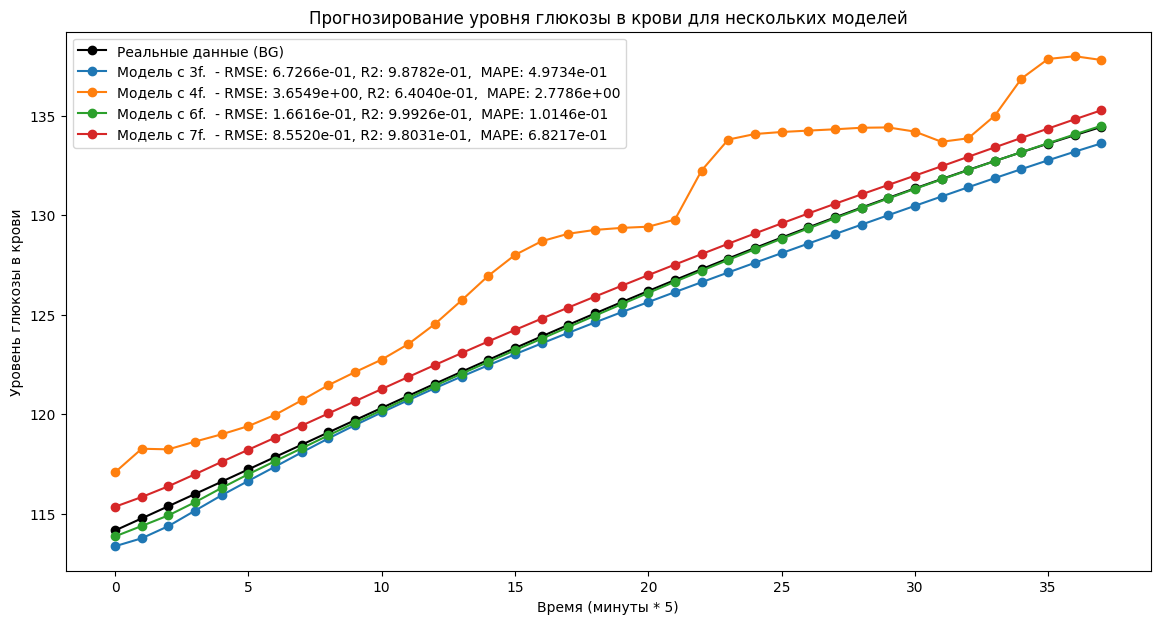

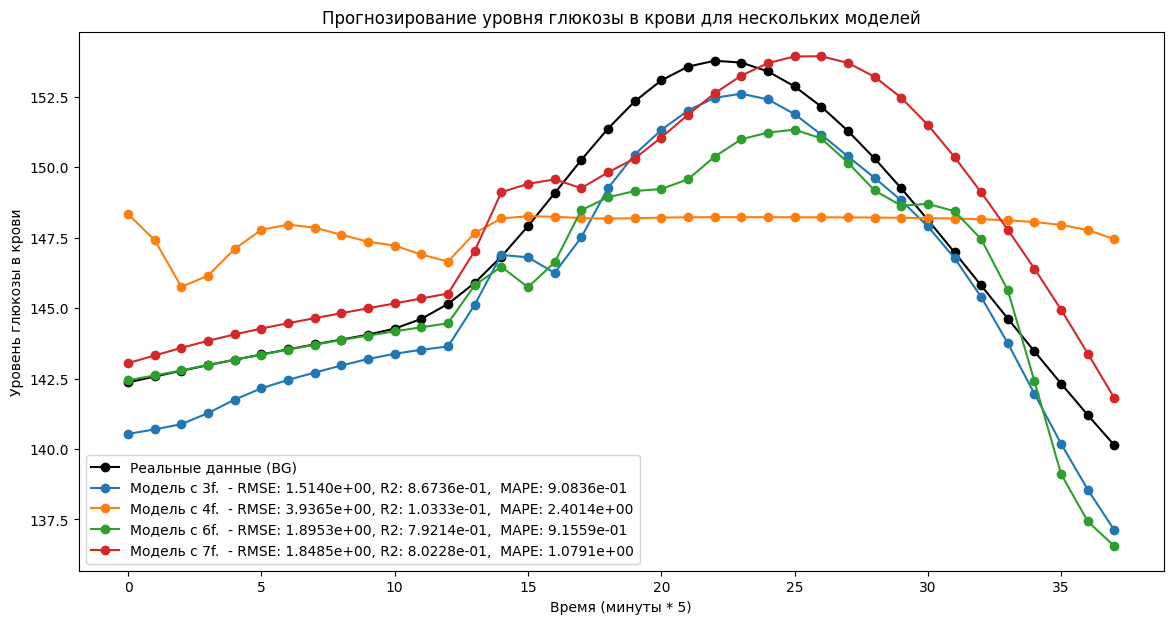

AVG Val loss [250/700] for model 1: 6.927260
AVG Val loss [250/700] for model 2: 17.508990
AVG Val loss [250/700] for model 3: 2.097027
AVG Val loss [250/700] for model 4: 2.115615
Epoch [300/700], AVG Loss for model 1: 3.322724
Epoch [300/700], AVG Loss for model 2: 2.300271
Epoch [300/700], AVG Loss for model 3: 0.976644
Epoch [300/700], AVG Loss for model 4: 0.710988


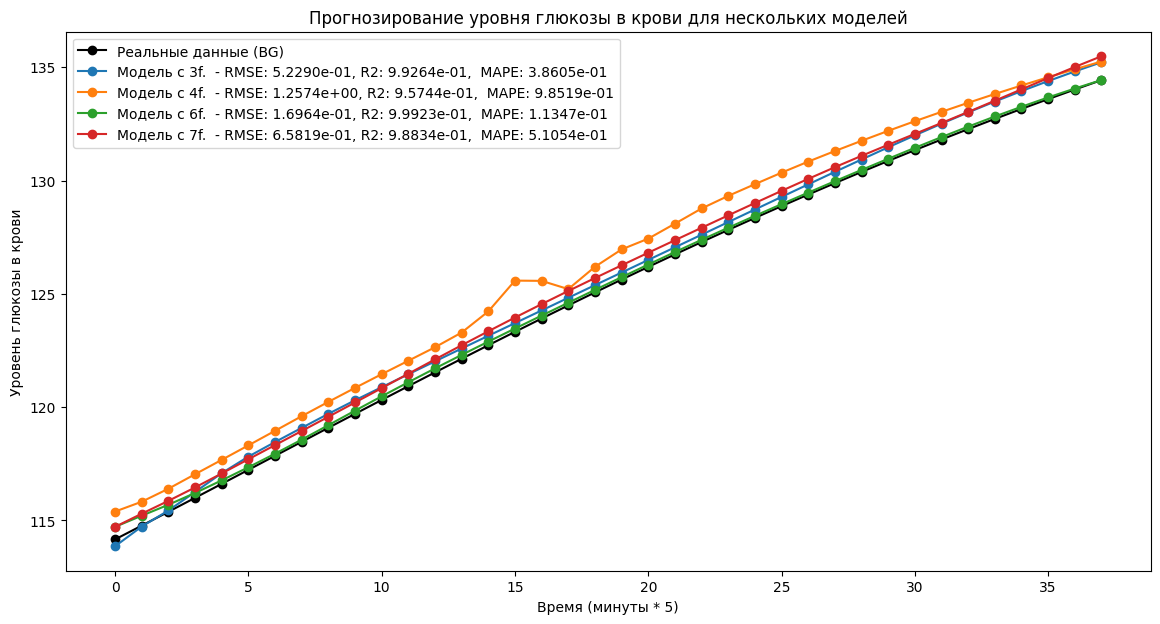

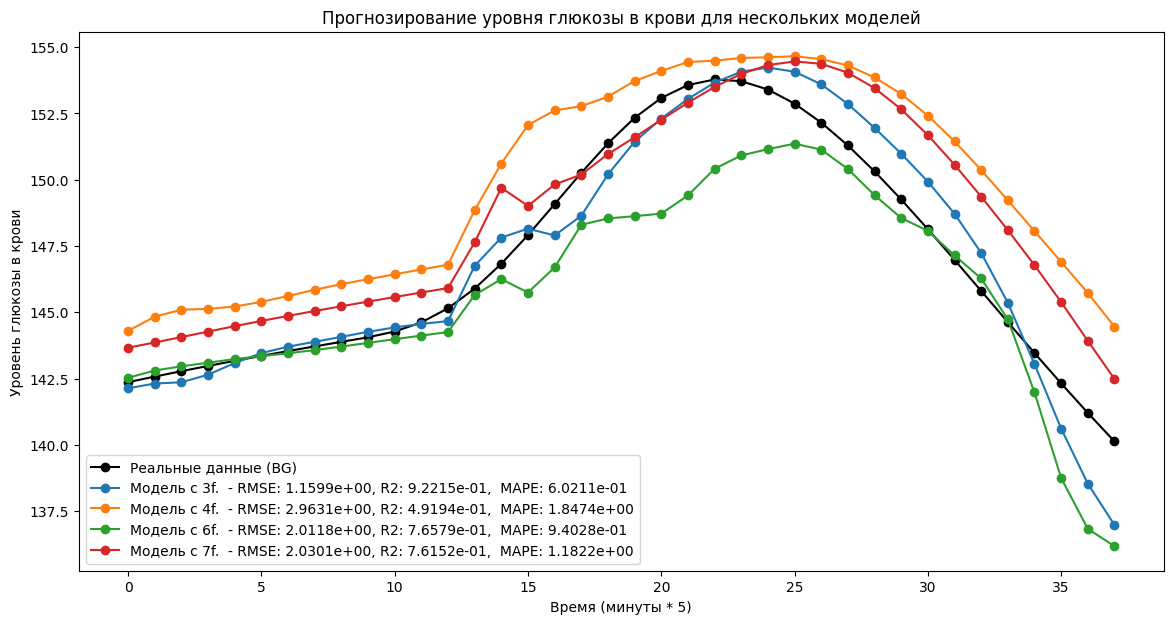

AVG Val loss [300/700] for model 1: 3.648124
AVG Val loss [300/700] for model 2: 4.023740
AVG Val loss [300/700] for model 3: 2.095174
AVG Val loss [300/700] for model 4: 2.183461
Epoch [350/700], AVG Loss for model 1: 2.477150
Epoch [350/700], AVG Loss for model 2: 1.450222
Epoch [350/700], AVG Loss for model 3: 1.457301
Epoch [350/700], AVG Loss for model 4: 0.593437


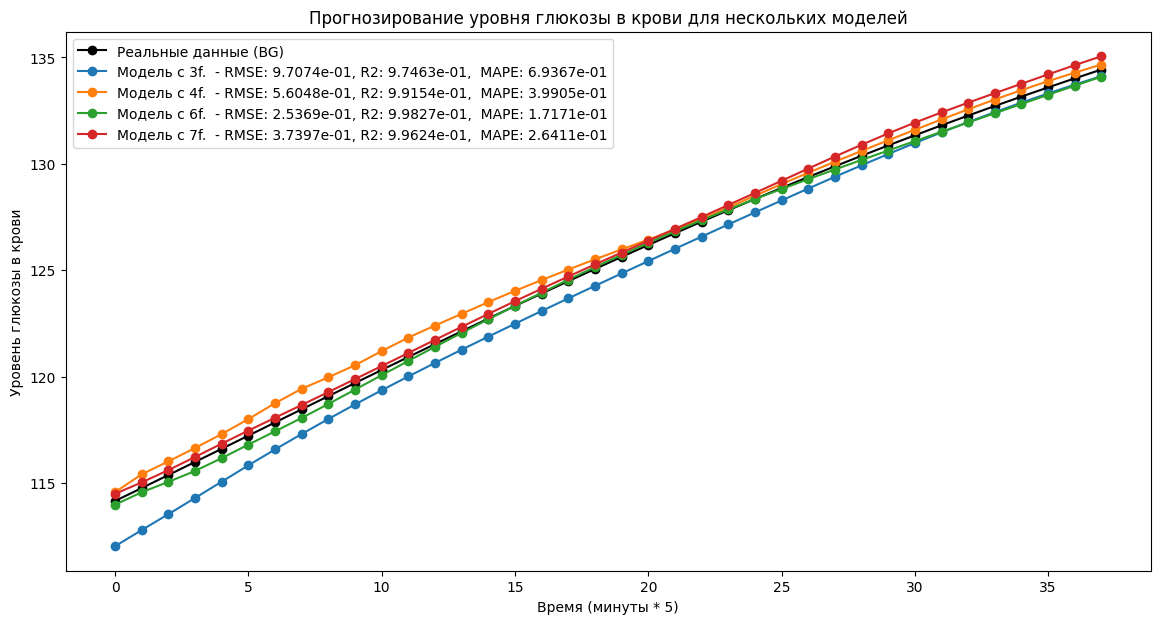

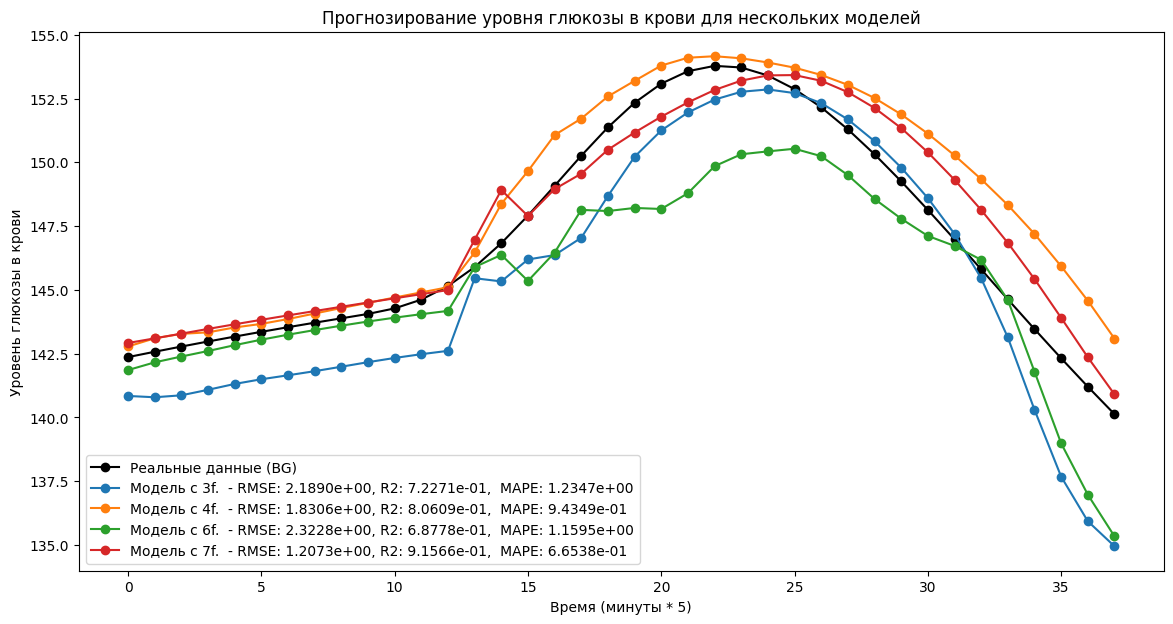

AVG Val loss [350/700] for model 1: 4.758572
AVG Val loss [350/700] for model 2: 2.010881
AVG Val loss [350/700] for model 3: 2.452936
AVG Val loss [350/700] for model 4: 1.253913
Epoch [400/700], AVG Loss for model 1: 2.682554
Epoch [400/700], AVG Loss for model 2: 1.302373
Epoch [400/700], AVG Loss for model 3: 1.223104
Epoch [400/700], AVG Loss for model 4: 0.467078


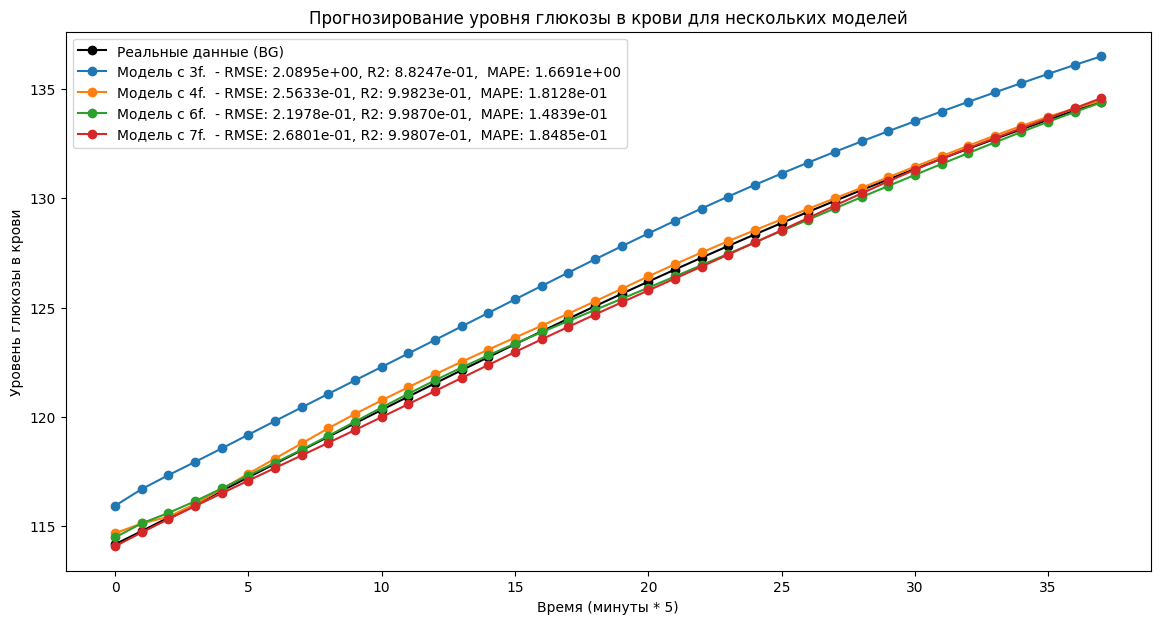

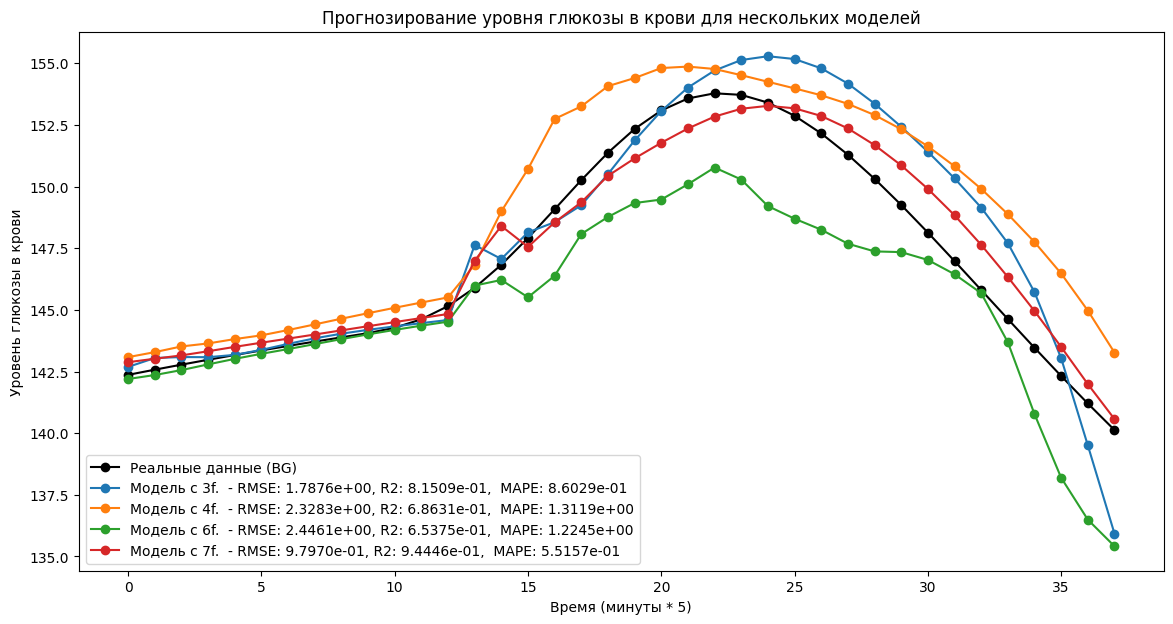

AVG Val loss [400/700] for model 1: 4.412424
AVG Val loss [400/700] for model 2: 2.539931
AVG Val loss [400/700] for model 3: 2.728935
AVG Val loss [400/700] for model 4: 1.260701
Epoch [450/700], AVG Loss for model 1: 1.764984
Epoch [450/700], AVG Loss for model 2: 0.974949
Epoch [450/700], AVG Loss for model 3: 0.686804
Epoch [450/700], AVG Loss for model 4: 0.371847


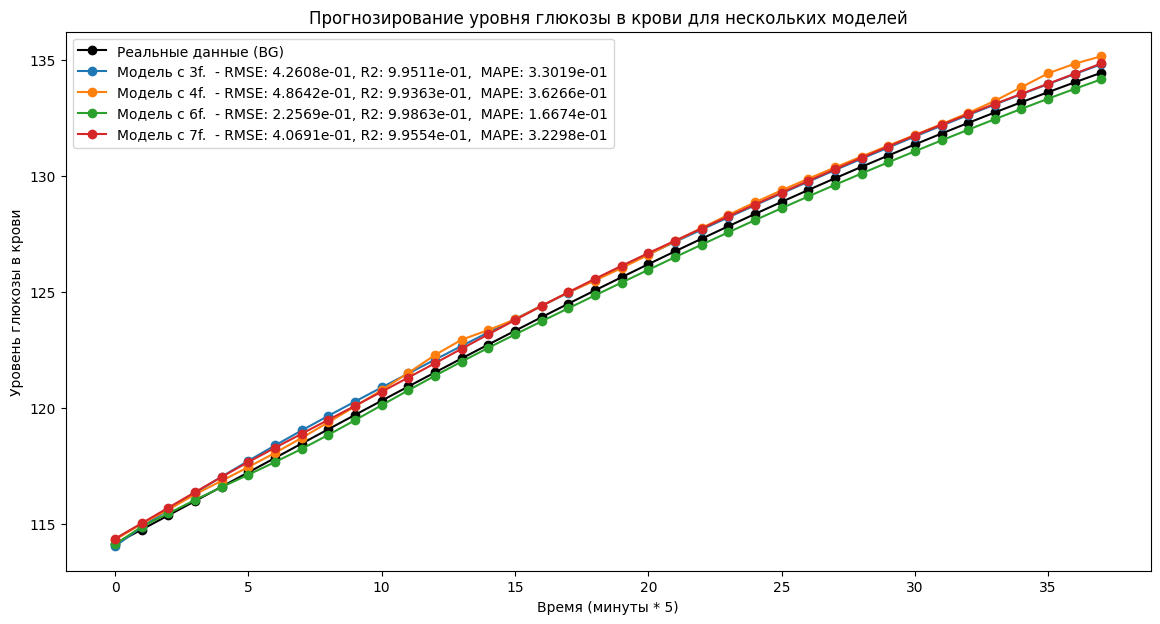

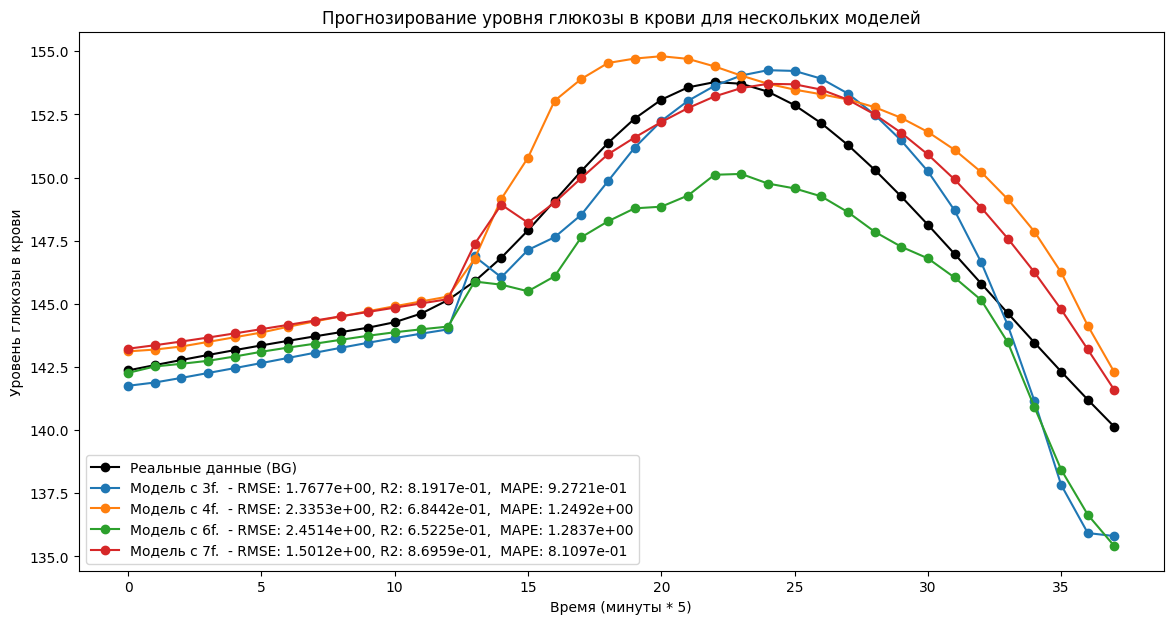

AVG Val loss [450/700] for model 1: 2.684574
AVG Val loss [450/700] for model 2: 2.421751
AVG Val loss [450/700] for model 3: 2.654165
AVG Val loss [450/700] for model 4: 1.640067
Epoch [500/700], AVG Loss for model 1: 2.251264
Epoch [500/700], AVG Loss for model 2: 0.933525
Epoch [500/700], AVG Loss for model 3: 1.027265
Epoch [500/700], AVG Loss for model 4: 0.337761


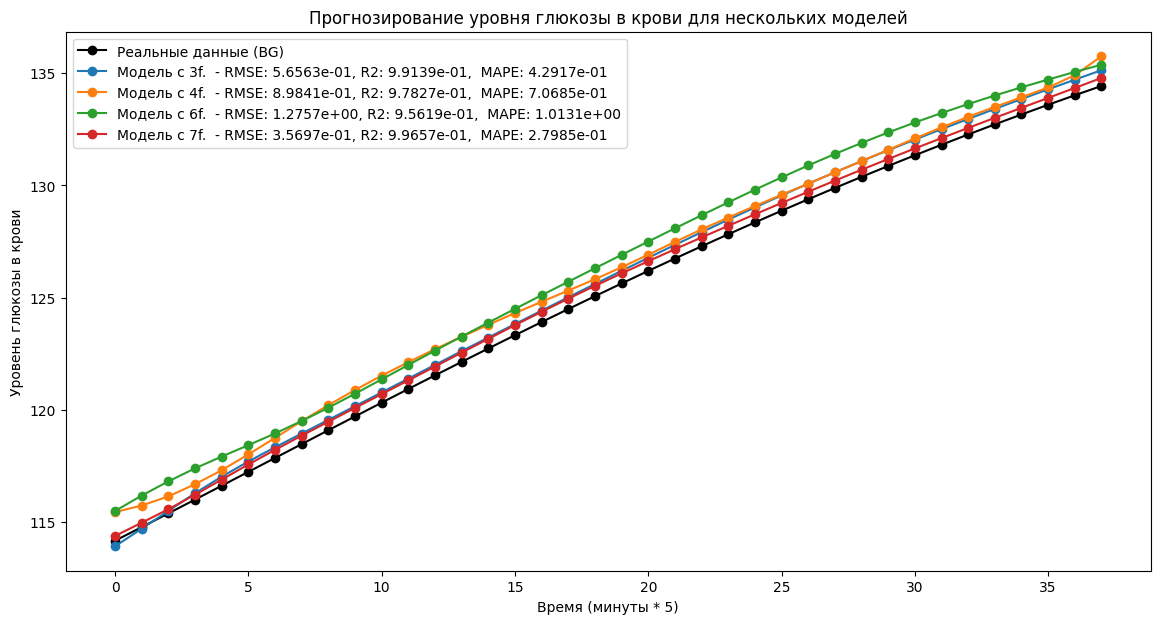

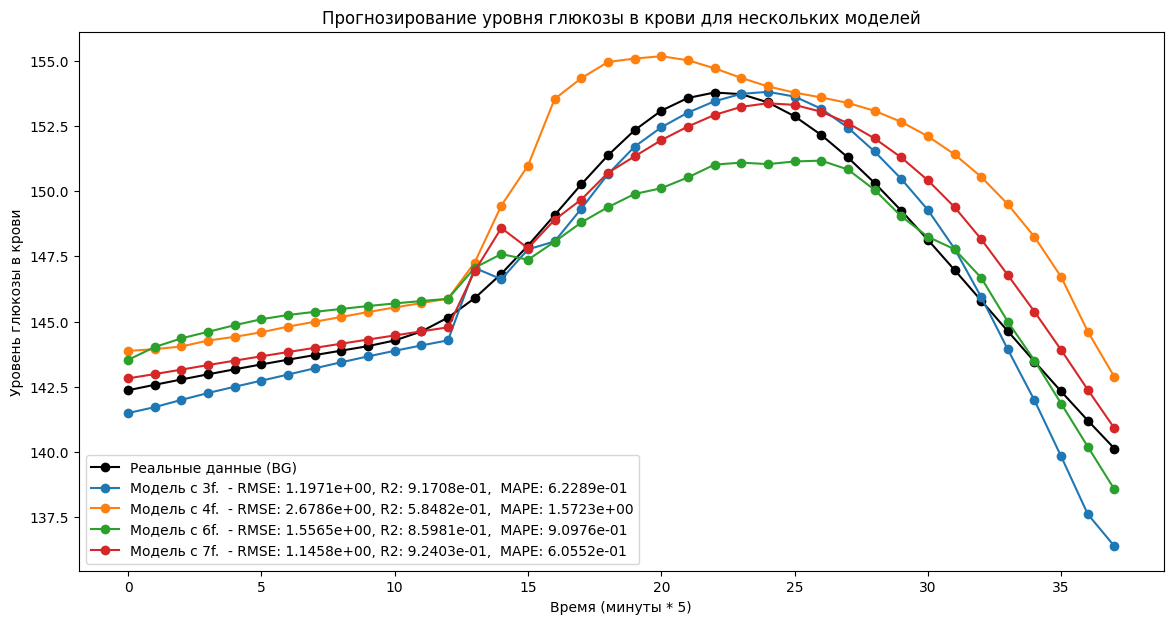

AVG Val loss [500/700] for model 1: 2.682509
AVG Val loss [500/700] for model 2: 2.720555
AVG Val loss [500/700] for model 3: 3.212808
AVG Val loss [500/700] for model 4: 1.374387
Epoch [550/700], AVG Loss for model 1: 1.458425
Epoch [550/700], AVG Loss for model 2: 0.792674
Epoch [550/700], AVG Loss for model 3: 0.647846
Epoch [550/700], AVG Loss for model 4: 0.349452


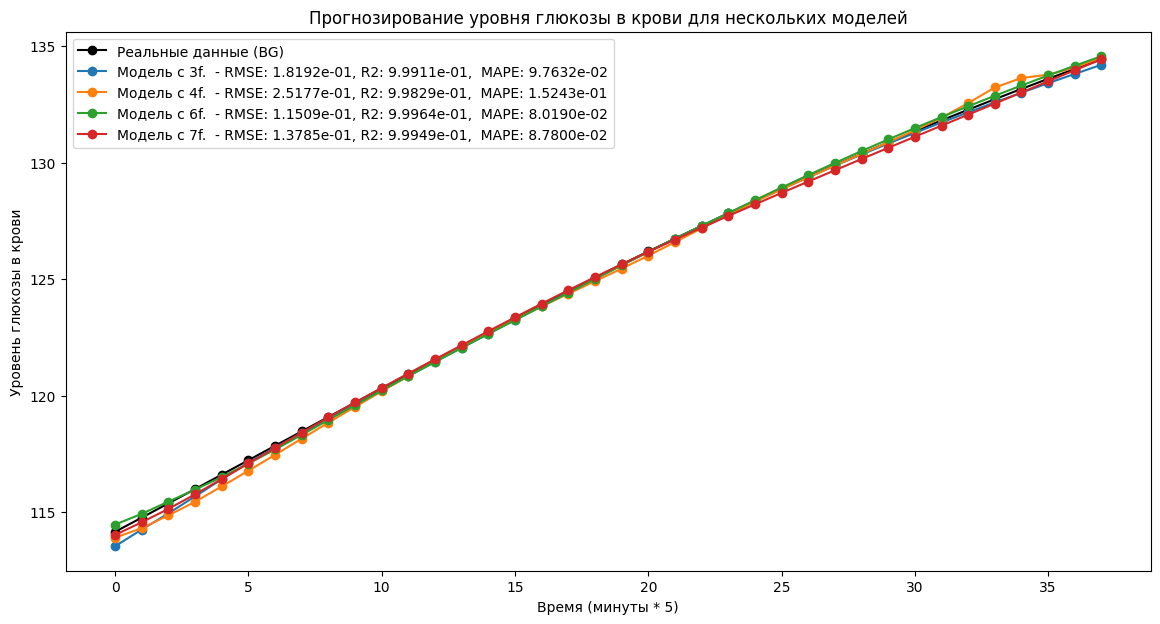

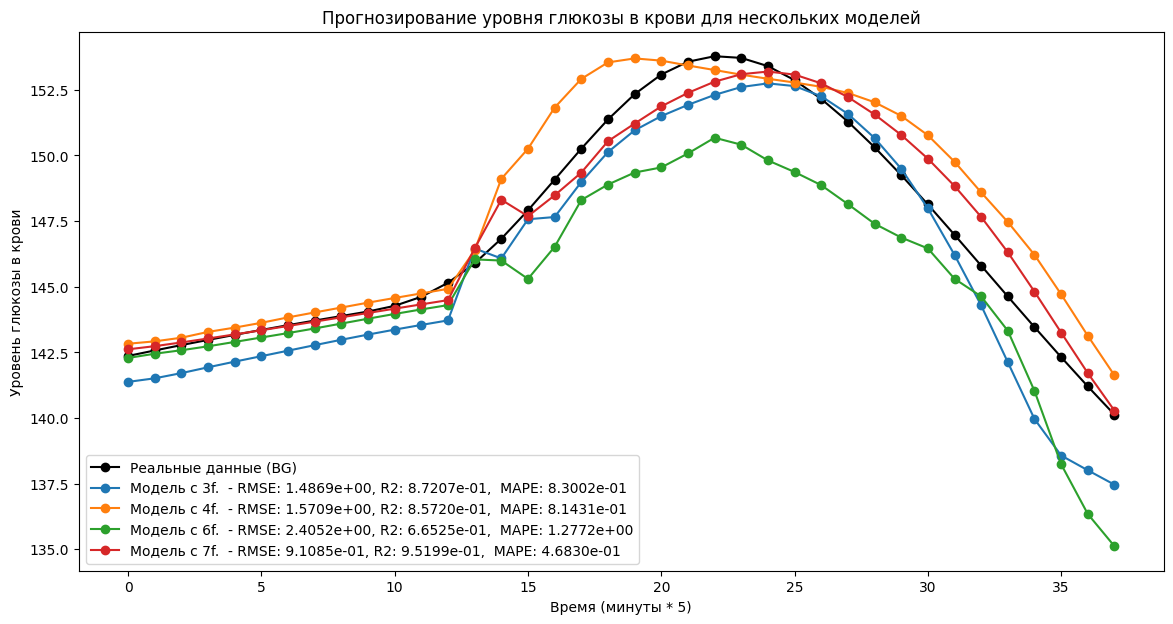

AVG Val loss [550/700] for model 1: 2.698773
AVG Val loss [550/700] for model 2: 1.927277
AVG Val loss [550/700] for model 3: 2.291396
AVG Val loss [550/700] for model 4: 1.377217
Epoch [600/700], AVG Loss for model 1: 1.593244
Epoch [600/700], AVG Loss for model 2: 0.816846
Epoch [600/700], AVG Loss for model 3: 0.637369
Epoch [600/700], AVG Loss for model 4: 0.334941


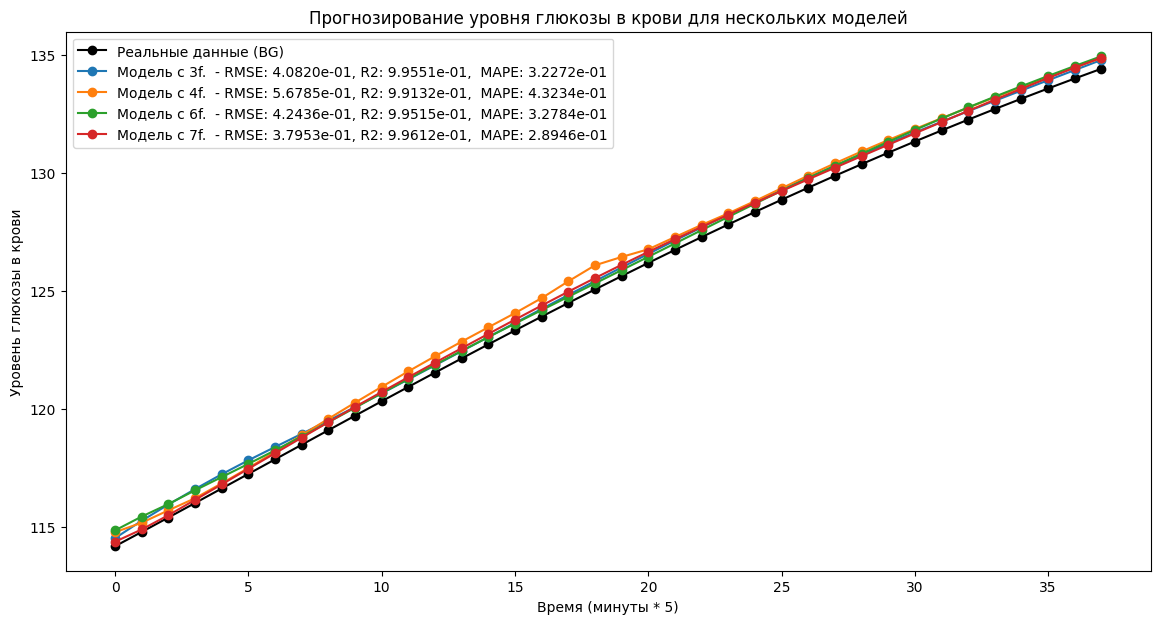

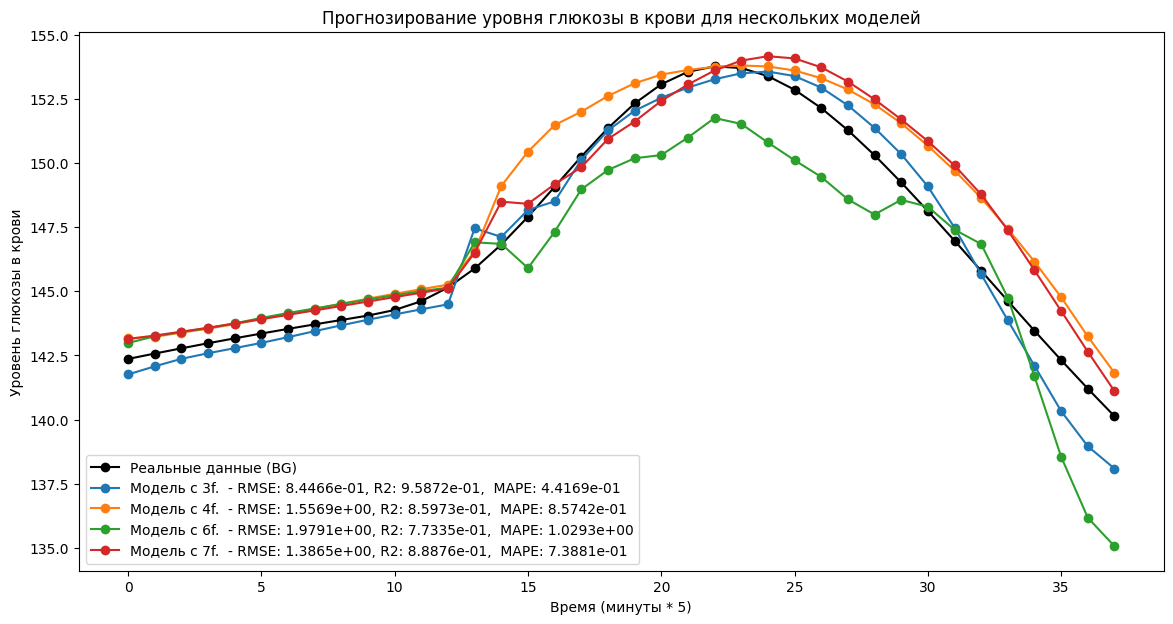

AVG Val loss [600/700] for model 1: 2.169701
AVG Val loss [600/700] for model 2: 1.616839
AVG Val loss [600/700] for model 3: 1.955986
AVG Val loss [600/700] for model 4: 1.745238
Epoch [650/700], AVG Loss for model 1: 1.269211
Epoch [650/700], AVG Loss for model 2: 0.885380
Epoch [650/700], AVG Loss for model 3: 0.933913
Epoch [650/700], AVG Loss for model 4: 0.287367


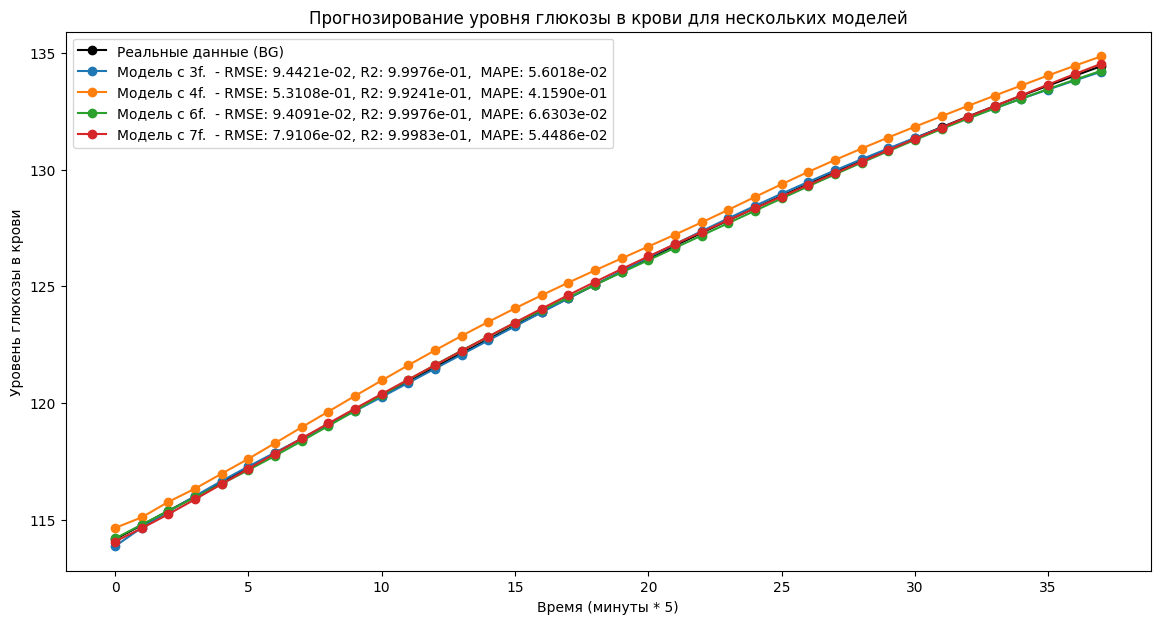

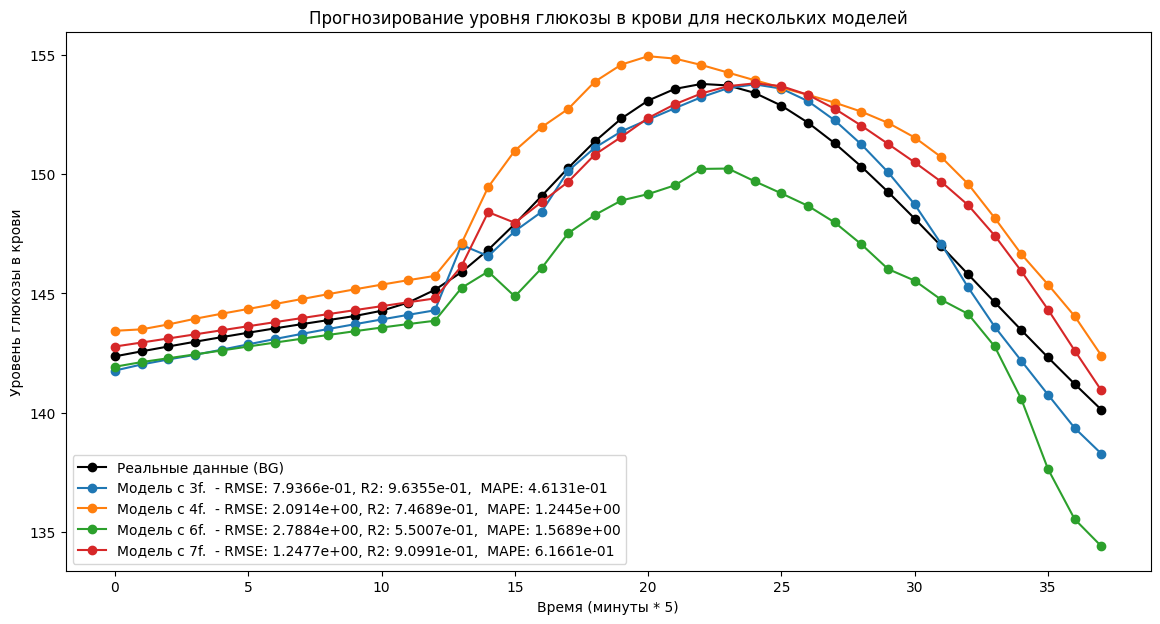

AVG Val loss [650/700] for model 1: 2.120860
AVG Val loss [650/700] for model 2: 2.340824
AVG Val loss [650/700] for model 3: 2.741292
AVG Val loss [650/700] for model 4: 1.426676
Epoch [700/700], AVG Loss for model 1: 1.335622
Epoch [700/700], AVG Loss for model 2: 0.557476
Epoch [700/700], AVG Loss for model 3: 0.558045
Epoch [700/700], AVG Loss for model 4: 0.366474


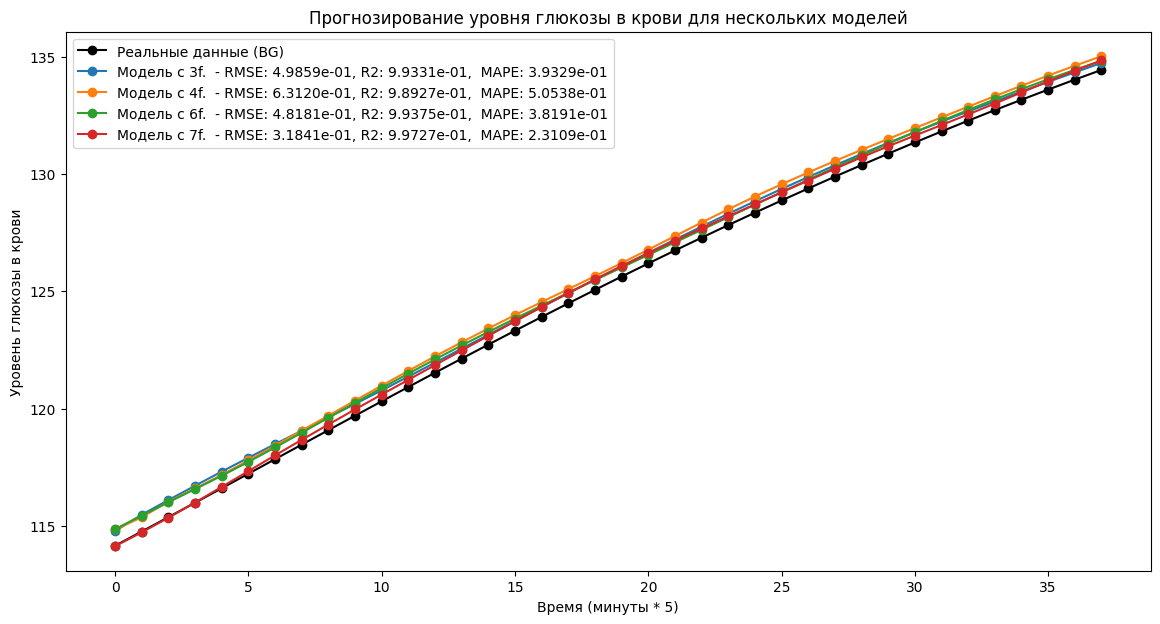

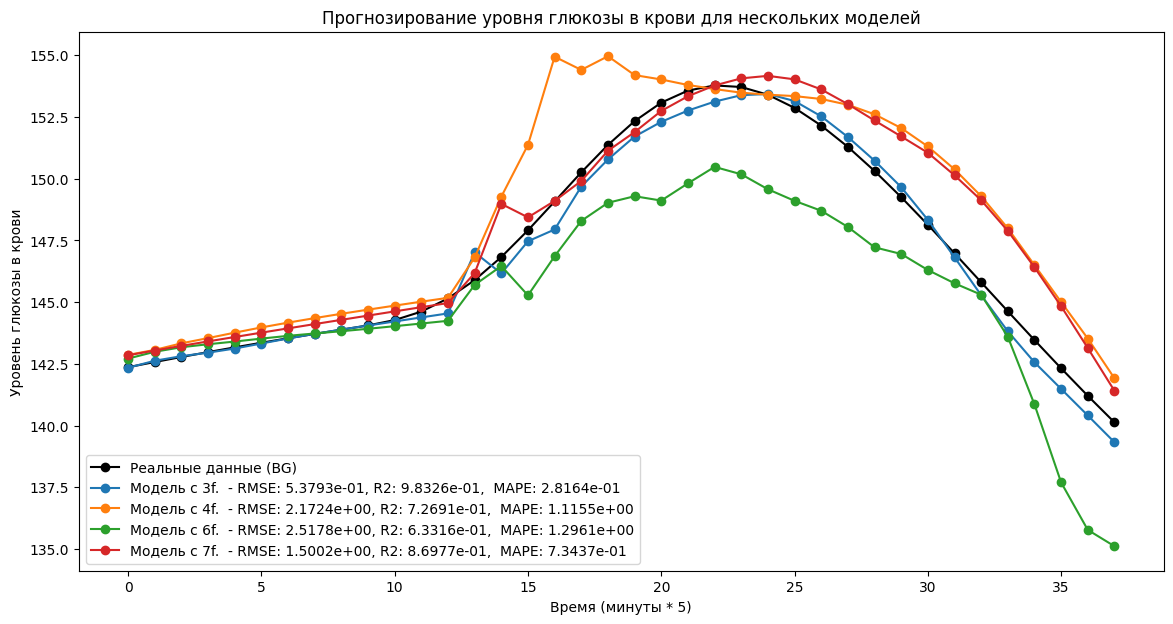

AVG Val loss [700/700] for model 1: 2.001938
AVG Val loss [700/700] for model 2: 1.664014
AVG Val loss [700/700] for model 3: 2.131752
AVG Val loss [700/700] for model 4: 1.656790


In [22]:
#Обучение
#horizon=30
#train_loader, validation_loader, test_loader, scaler = create_dataloader(horizon, data_sim, data_hov5, data_hov10, data_hov15, data_hov30)

model1 = LSTMModel(input_size=3, hidden_size=128, num_layers=2).to(device)
model2 = LSTMModel(input_size=4, hidden_size=128, num_layers=2).to(device)
model3 = LSTMModel(input_size=6, hidden_size=128, num_layers=2).to(device)
model4 = LSTMModel(input_size=7, hidden_size=128, num_layers=2).to(device)

criterion = nn.MSELoss()

optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.01)
optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.01)

num_epochs = 700

models = [model1, model2, model3, model4]
optimizers = [optimizer1, optimizer2, optimizer3, optimizer4]
feature_indices = [
    [0, 1, 2],         # Первые 3 признака для первой модели
    [0, 1, 2, 3],      # Первые 3 признака + 1 (Hovorka)
    [0, 1, 2, 4, 5, 6], # Первые 3 признака + 3 дополнительных
    [0, 1, 2, 3, 4, 5, 6] # Все признаки
]

train_multiple_models(models, optimizers, criterion, train_loader, validation_loader, num_epochs, scaler, device, feature_indices)



288


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

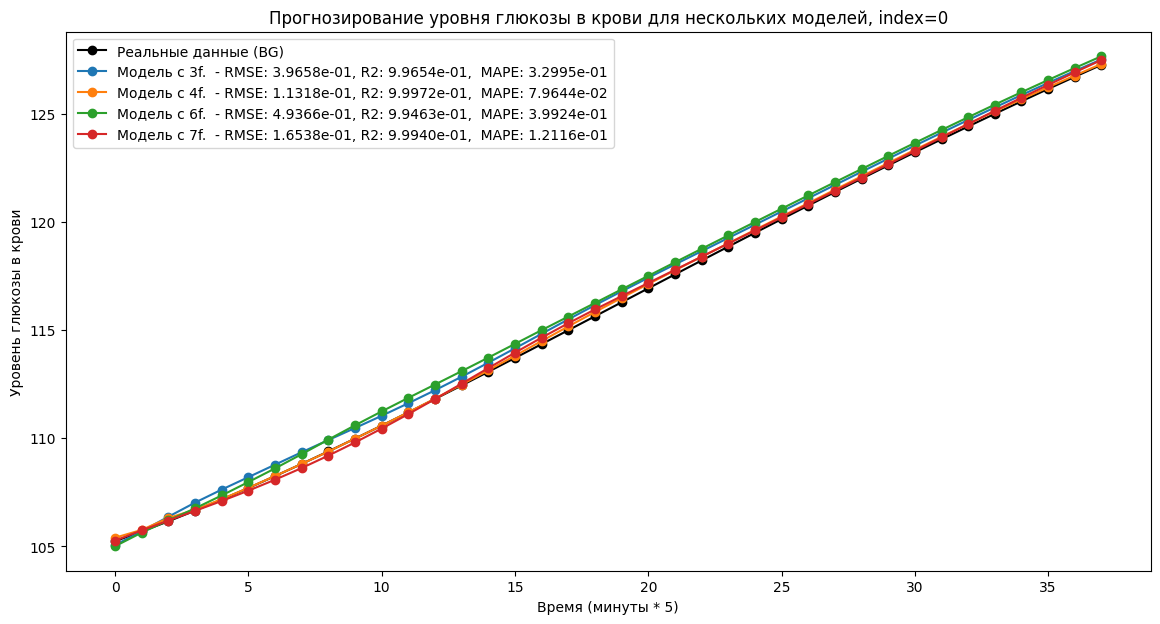

Results saved to evaluate0.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

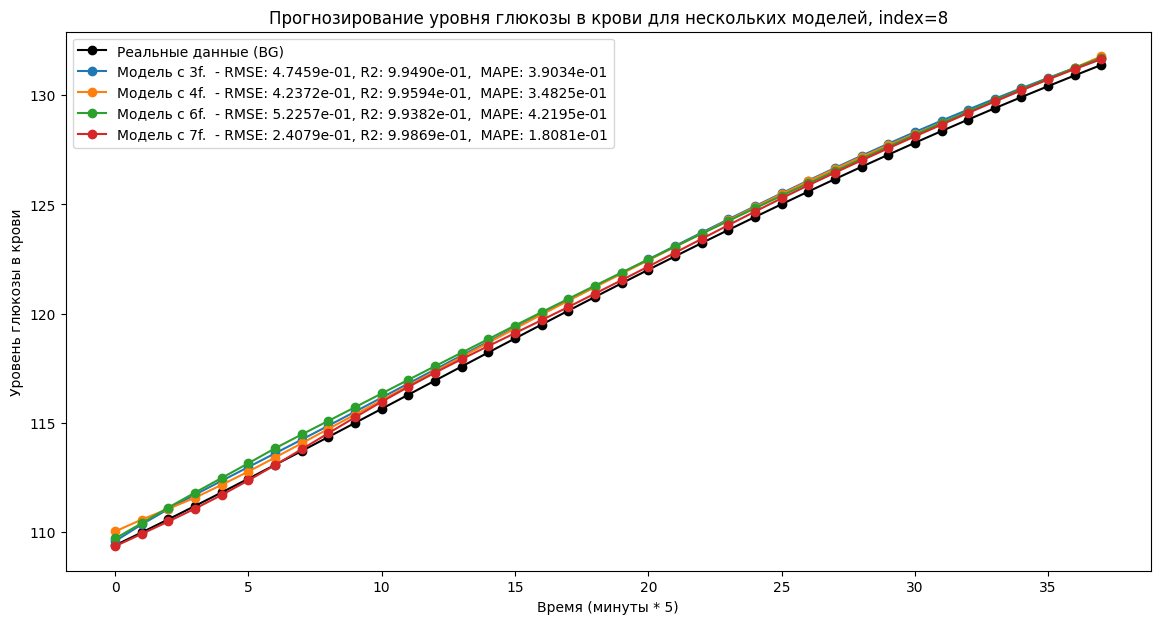

Results saved to evaluate8.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

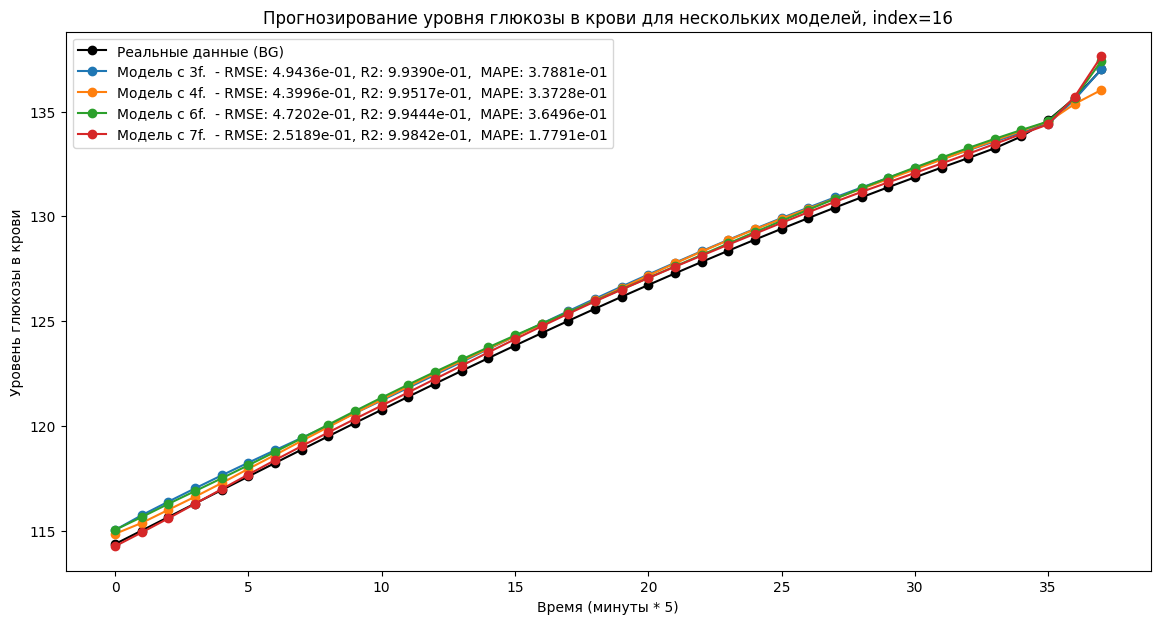

Results saved to evaluate16.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

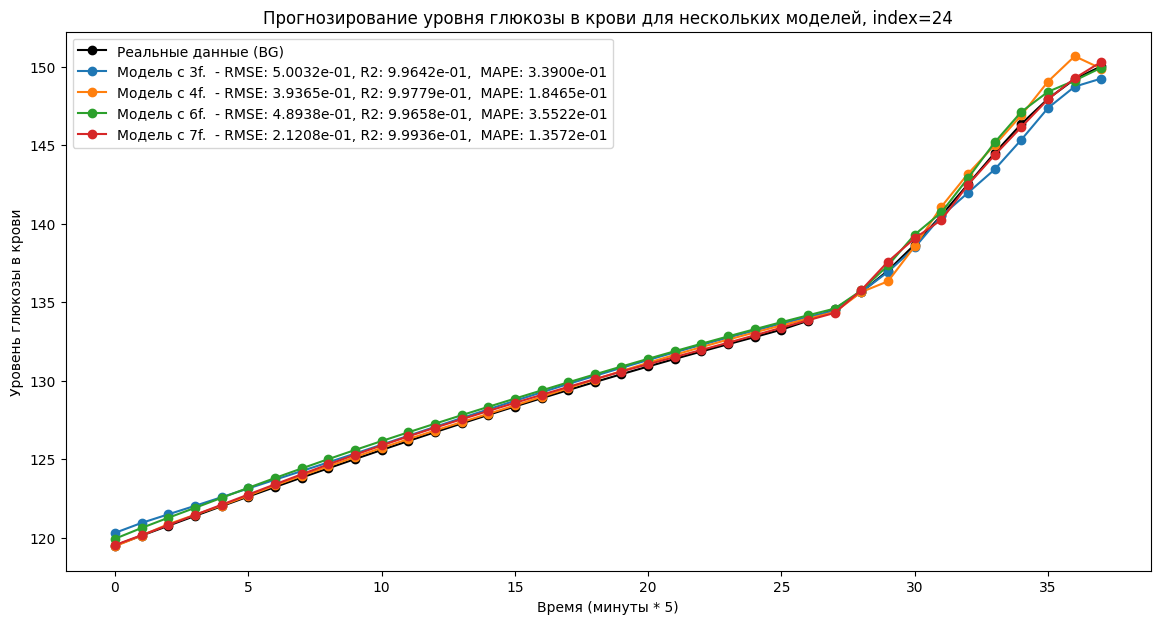

Results saved to evaluate24.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

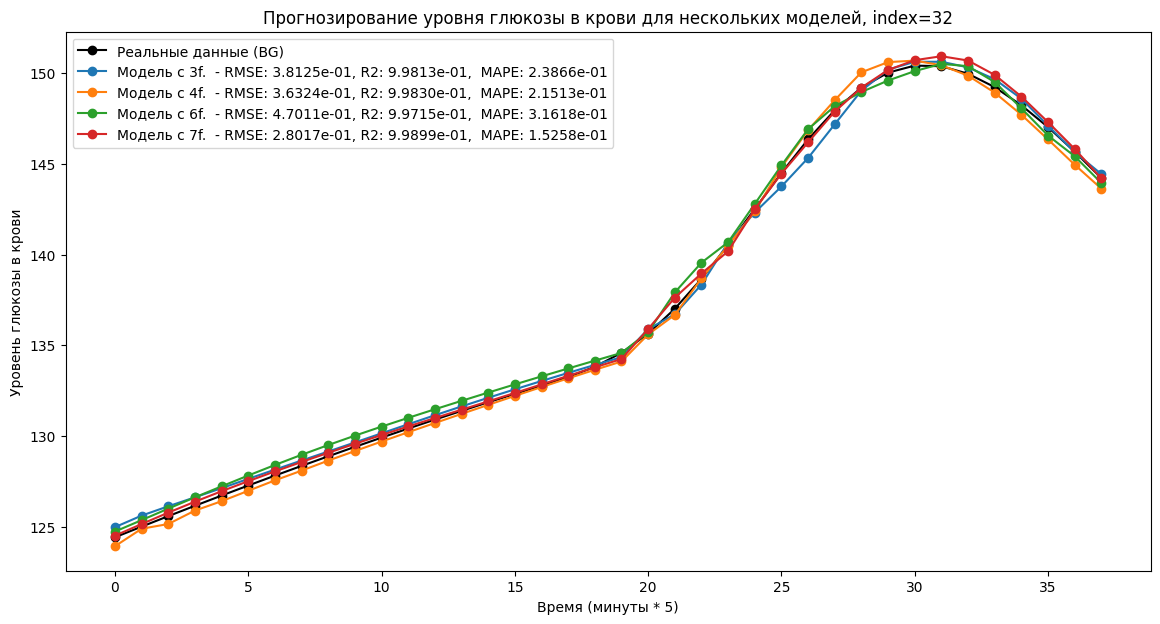

Results saved to evaluate32.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

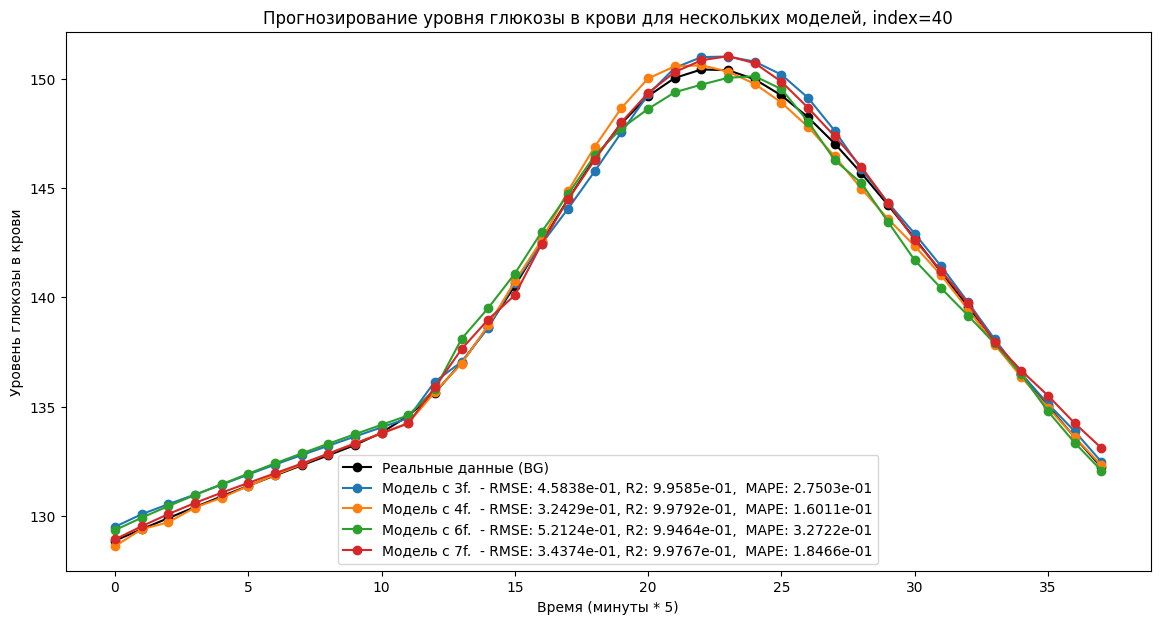

Results saved to evaluate40.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

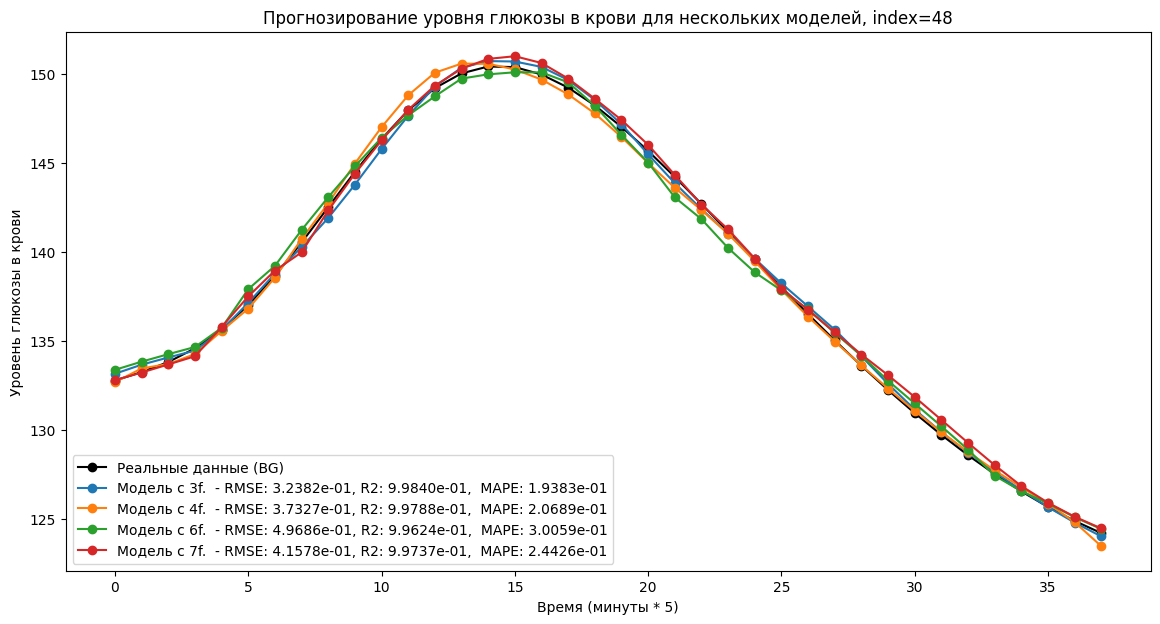

Results saved to evaluate48.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

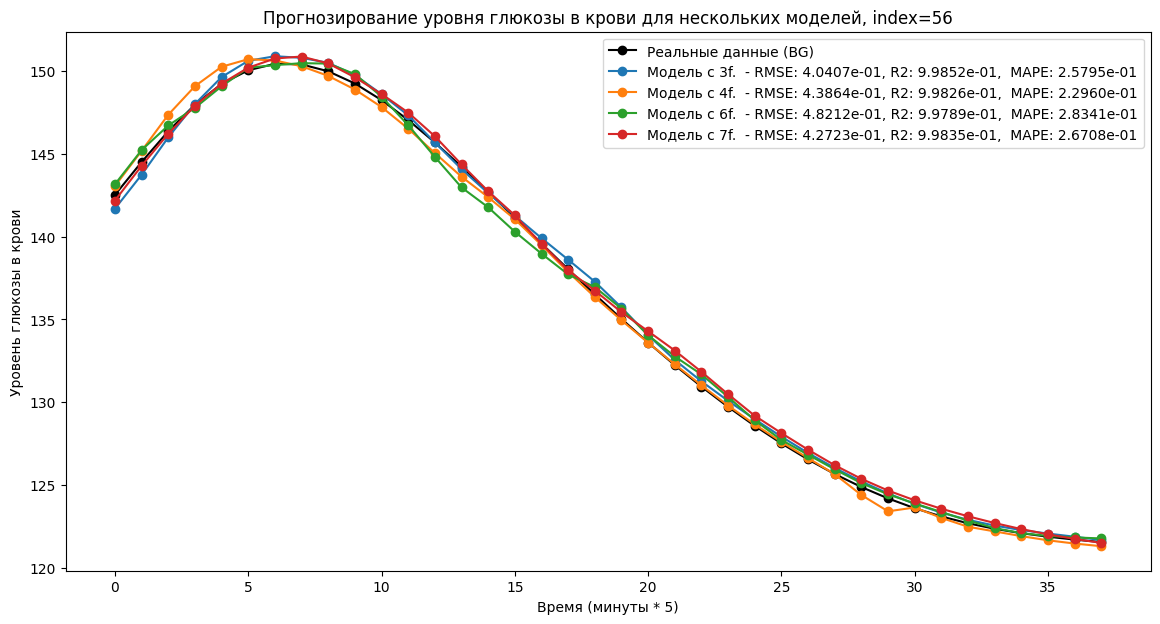

Results saved to evaluate56.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

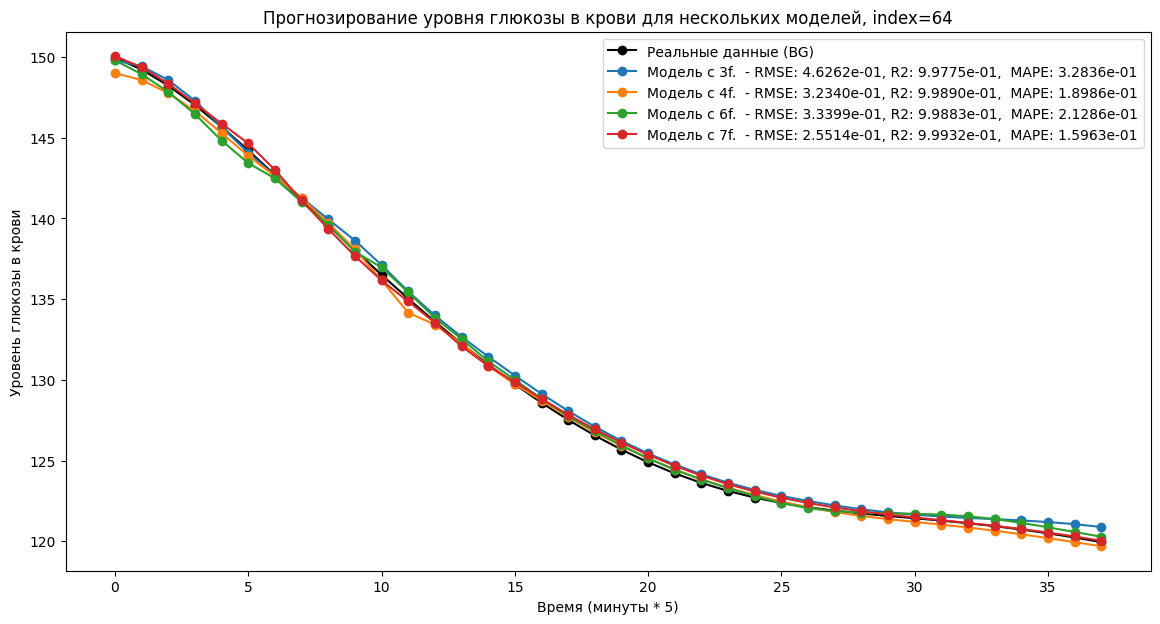

Results saved to evaluate64.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

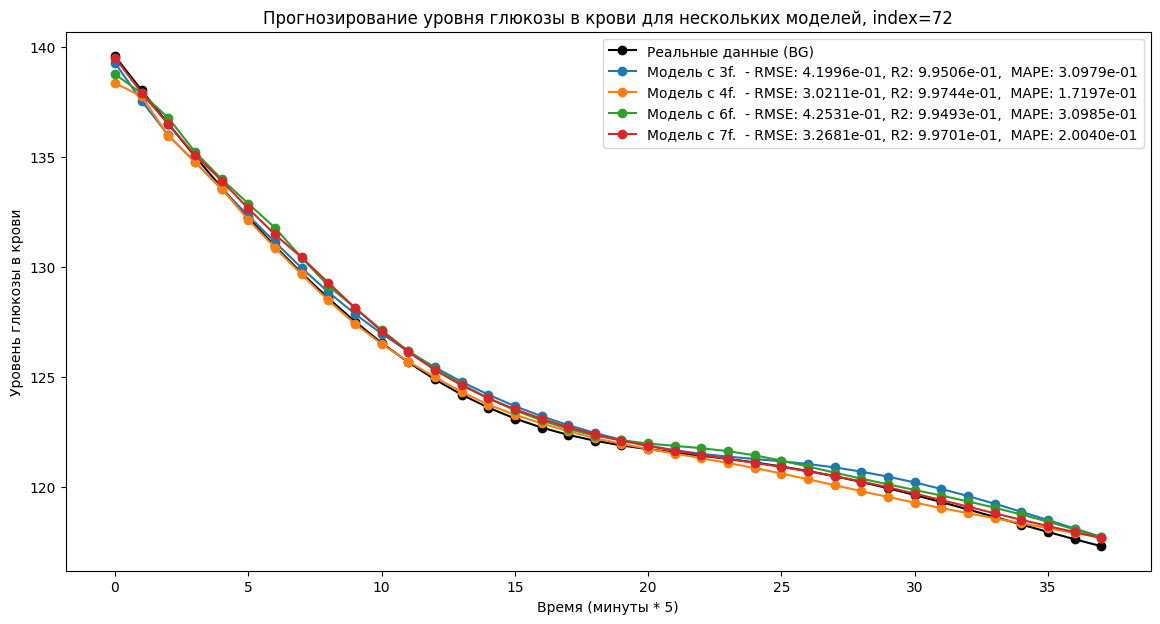

Results saved to evaluate72.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

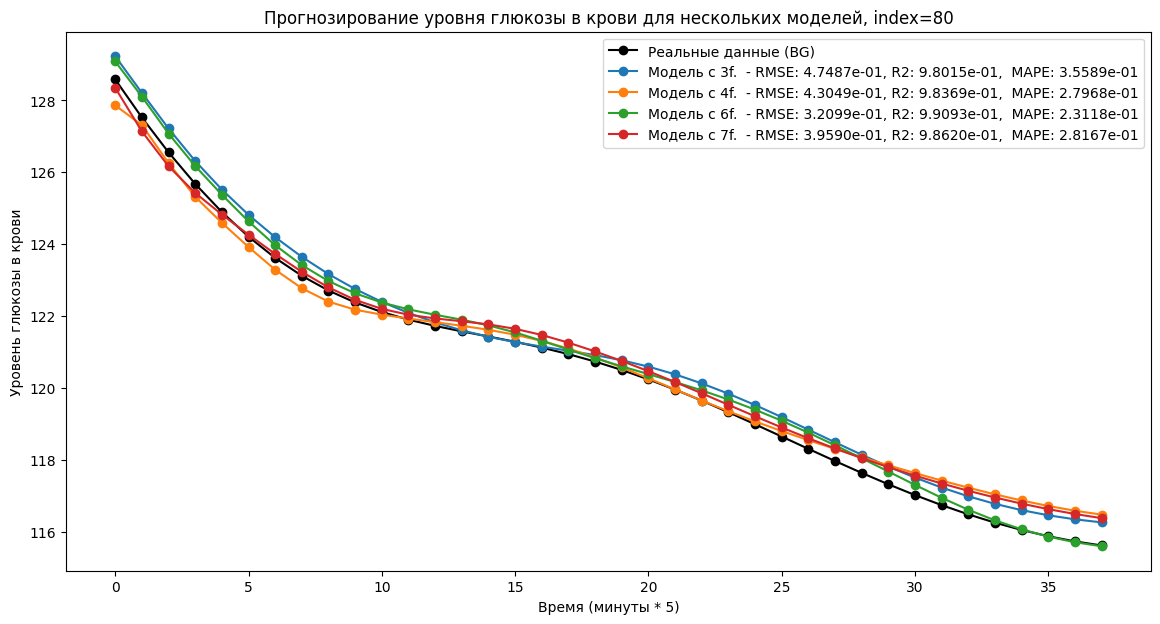

Results saved to evaluate80.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

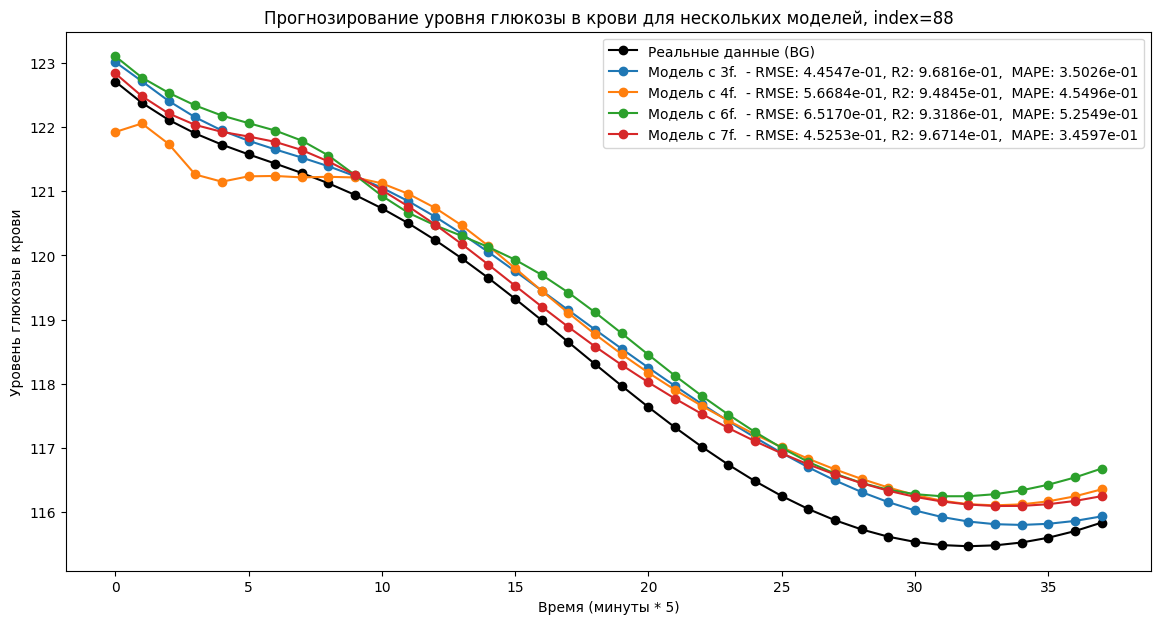

Results saved to evaluate88.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

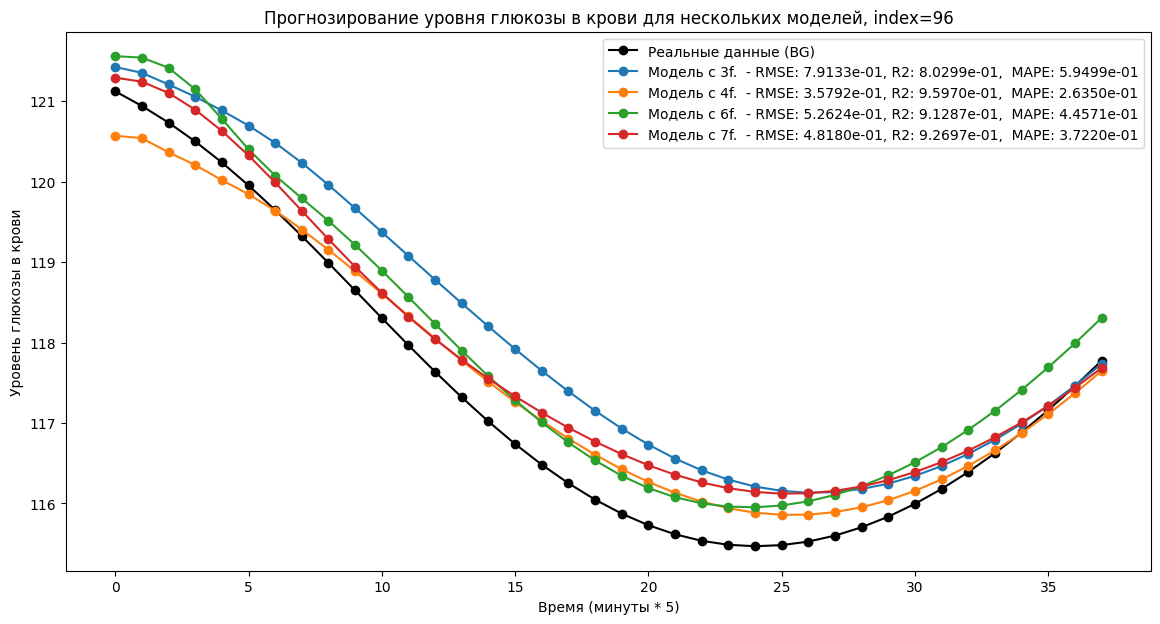

Results saved to evaluate96.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

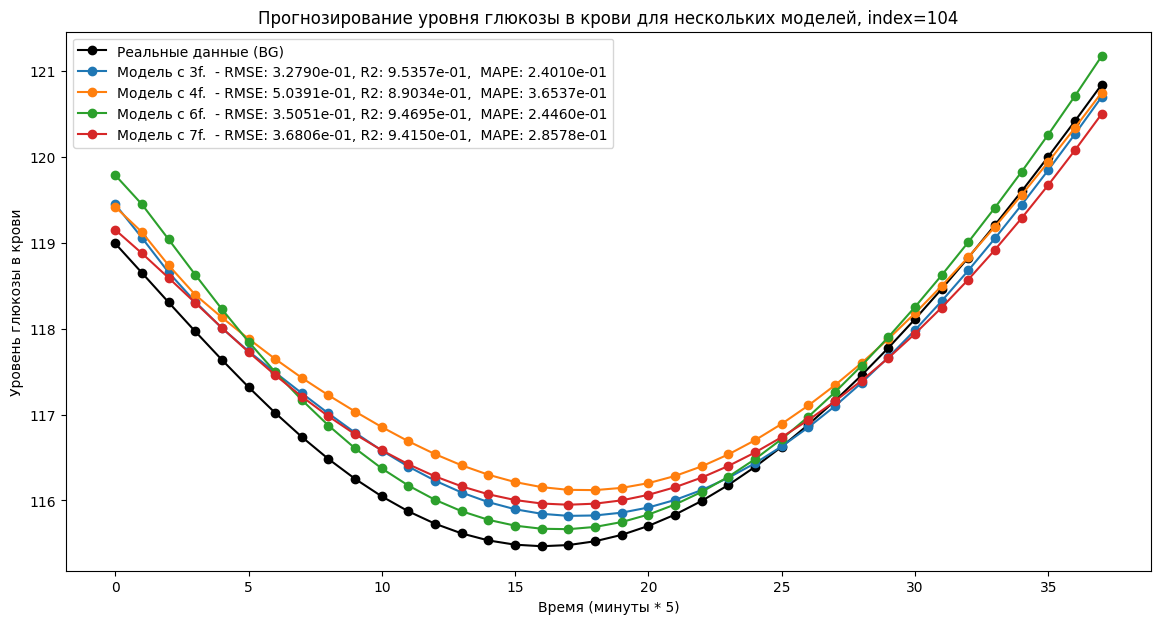

Results saved to evaluate104.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

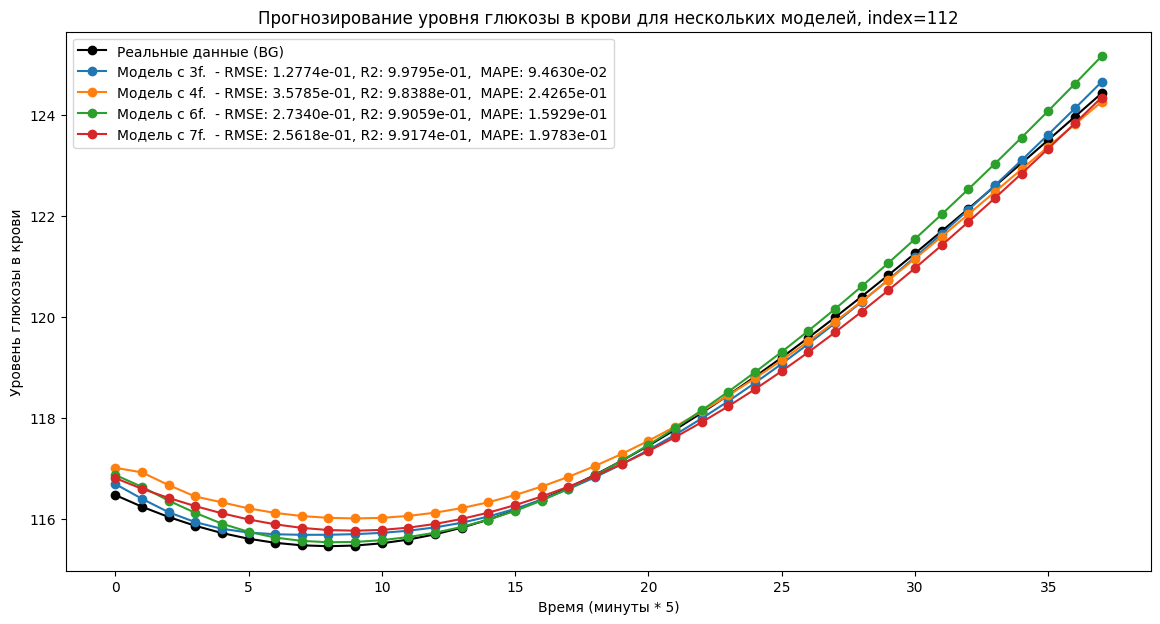

Results saved to evaluate112.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

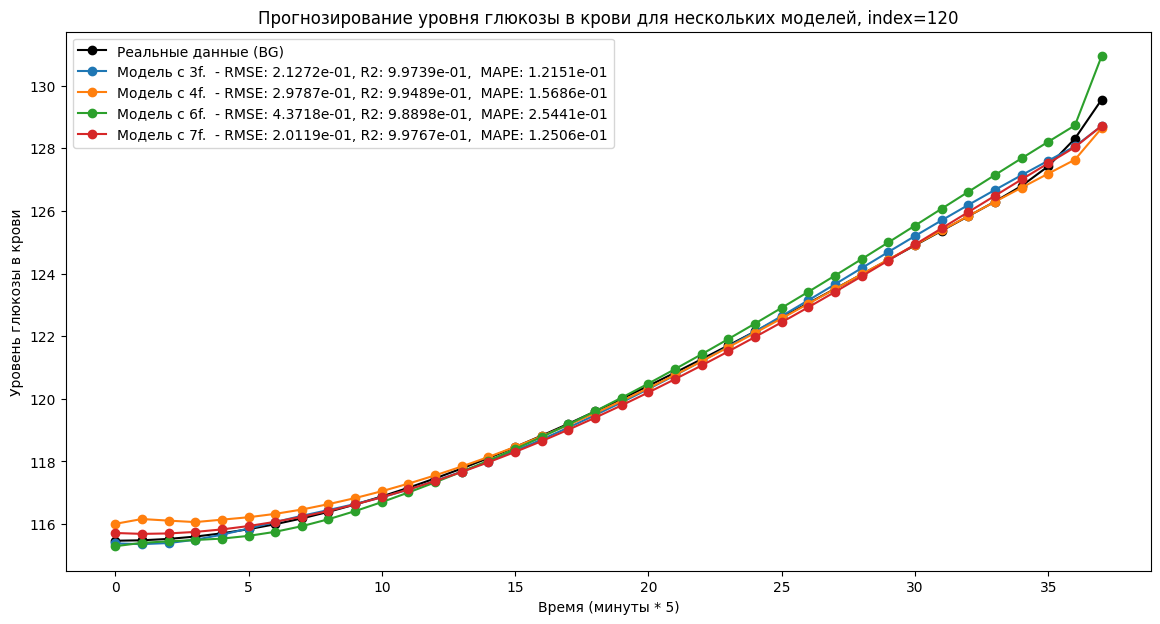

Results saved to evaluate120.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

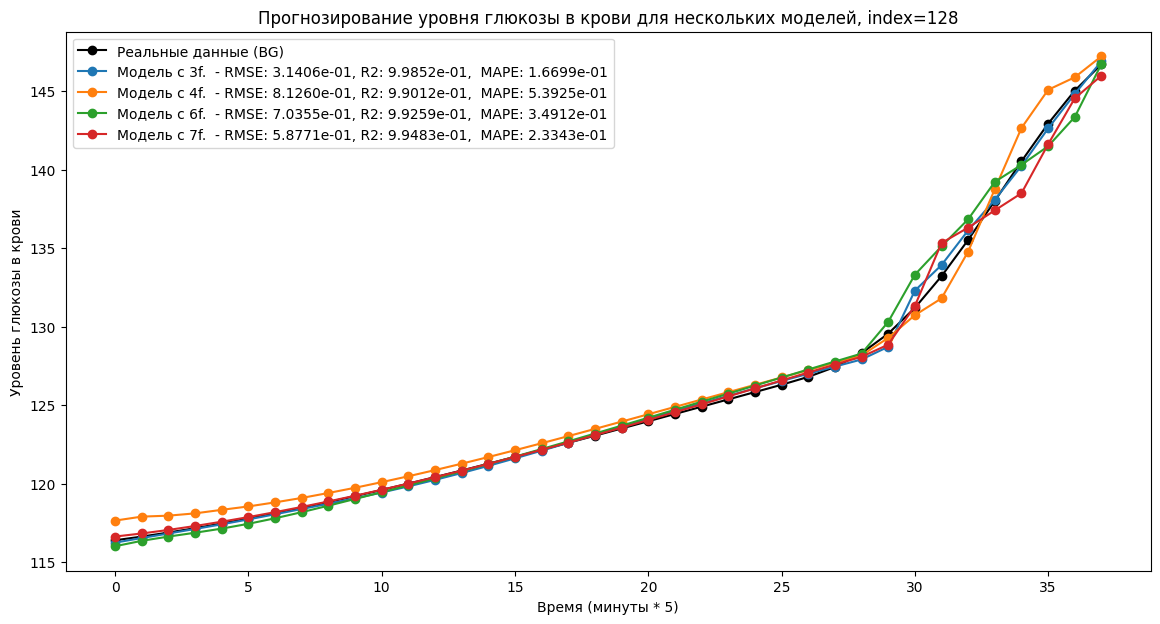

Results saved to evaluate128.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

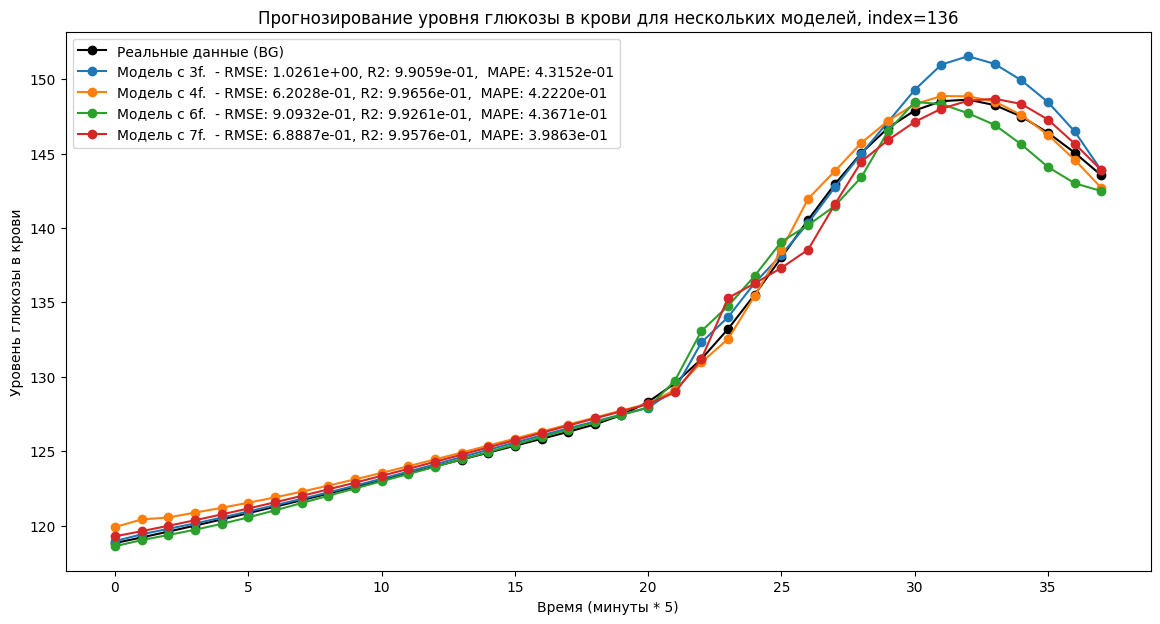

Results saved to evaluate136.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

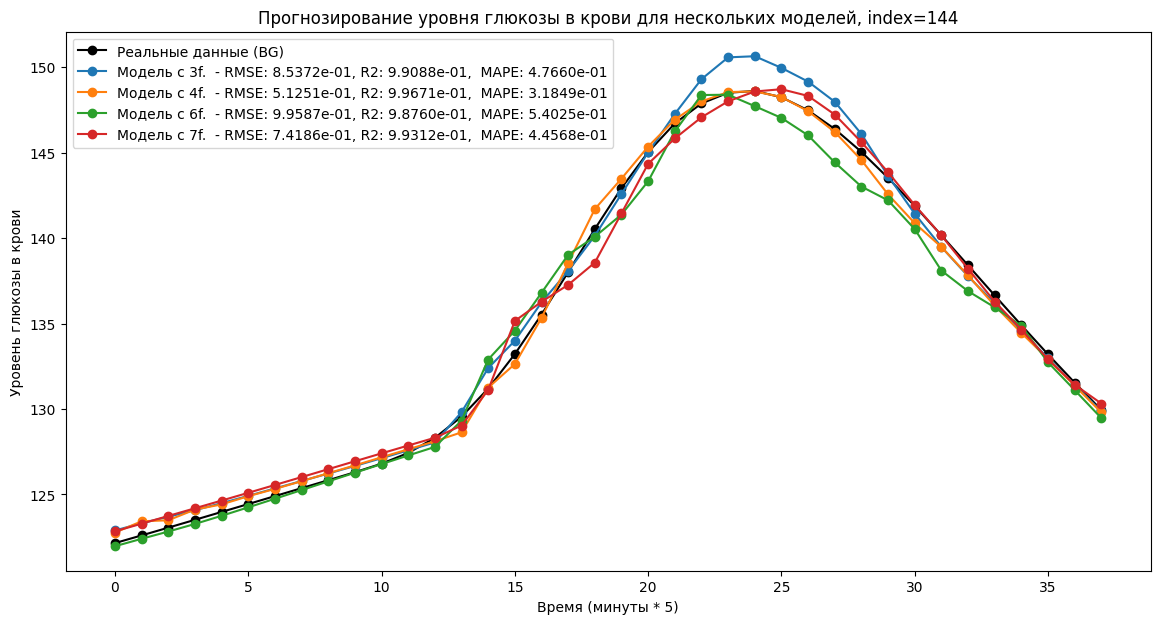

Results saved to evaluate144.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

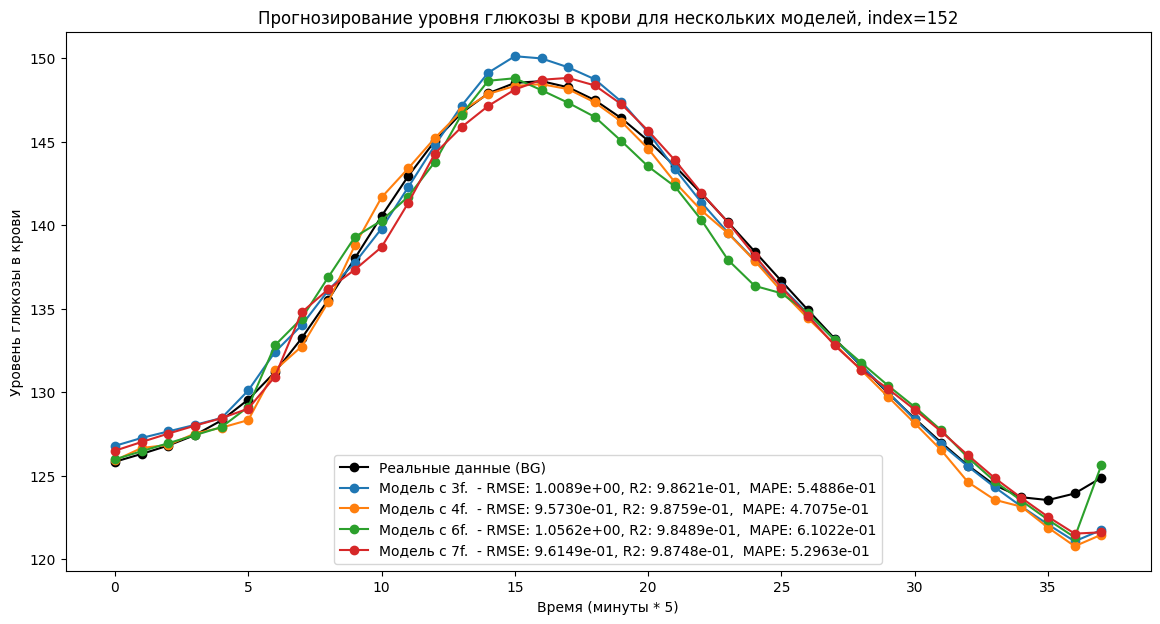

Results saved to evaluate152.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
#TEST
print(len(validation_data))

#Вывод 20 тестов
#for i in range(25):
#  evaluate_both_model(model1, model2, test_loader, scaler1, scaler2, device, i*10)



models = [model1, model2, model3, model4]  # Модели с разными наборами признаков
feature_indices = [
    [0, 1, 2],        # Первые 3 признака для первой модели
    [0, 1, 2, 3],     # Первые 3 признака + 1 (Hovorka)
    [0, 1, 2, 4, 5, 6],  # Первые 3 признака + 3 дополнительных
    [0, 1, 2, 3, 4, 5, 6]  # Все признаки
]

# Оценка на тестовом наборе
for i in range(20):
  evaluate_multiple_models(models, test_loader, scaler, device, criterion, index=i*8, feature_indices=feature_indices)



Количество батчей в test_loader: 216
AA


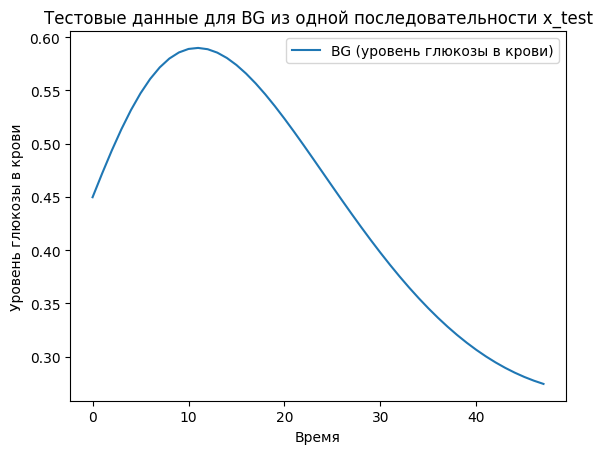

In [ ]:
import matplotlib.pyplot as plt
# Выводим количество батчей в test_loader
print(f"Количество батчей в test_loader: {len(test_loader)}")

# Извлекаем одну последовательность из test_loader
count=0
for x_test, _ in test_loader:
  if(count==10):
    print("AA")
    # Предполагаем, что BG — это первый признак (индекс 0)
    bg_values = x_test[0, :, 0].cpu().numpy()  # Извлекаем только первый признак для одной последовательности
    break  # Достаточно одного батча для одной последовательности
  count+=1


# Построение графика только для BG одной последовательности
plt.plot(bg_values, label='BG (уровень глюкозы в крови)')
plt.xlabel('Время')
plt.ylabel('Уровень глюкозы в крови')
plt.title('Тестовые данные для BG из одной последовательности x_test')
plt.legend()
plt.show()


In [25]:
# Сохранить модель (включая её параметры)
torch.save(models[0].state_dict(), 'model1.pth')
torch.save(models[1].state_dict(), 'model2.pth')
torch.save(models[2].state_dict(), 'model3.pth')
torch.save(models[3].state_dict(), 'model4.pth')

